<a href="https://colab.research.google.com/github/yuchanleee/iot-ids-ml/blob/main/Ids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 데이터 전처리**

In [ ]:
# @title
''' 데이터 크기
전체: 2,219,201행 × 63컬럼
train: 1,554,327
val: 331,993
test: 332,881
-----------------------------------------------------------------------------------------------------------------------------------------------
이 결과를 종합하면 원인이 한 가지라기보다, “중복/누수 + 매우 강한 분리 feature + 데이터 구조 자체의 쉬움”이 동시에 겹친 상태로 보는 게 맞다.

즉 결론부터 말하면:

최종 결론

현재 F1=1.0000은 모델이 진짜로 실전 일반화 성능이 완벽해서가 아니라,
주로 아래 이유들 때문에 과대평가되었을 가능성이 매우 높다.

train-test 완전 중복 행이 16.96% 존재
tcp.dstport 같은 단일 feature만으로도 F1=0.9596
feature group을 여러 개 통째로 제거해도 다른 group들이 정답을 거의 그대로 복원
그래서 모델이 “깊이 있는 패턴 학습”을 했다기보다, 거의 식별자에 가까운 feature 조합으로 문제를 풀고 있다
1. 지금 결과가 말해주는 것

너가 준 핵심 결과를 다시 구조화하면 이렇다.

A. 중복 검사
test set 중 train과 완전 동일한 행: 56448 / 332881 (16.96%)

이건 작지 않다.
테스트 샘플 6개 중 1개꼴로 train에 완전히 똑같은 row가 있다는 뜻이다.

이건 평가를 오염시킨다.

왜냐하면 모델 입장에서는

“처음 보는 테스트 데이터”가 아니라
“이미 본 적 있는 패턴”이 꽤 많이 들어온 것과 비슷하기 때문이다.

다만 이것만으로 모든 걸 설명하진 못한다.
16.96% 중복만으로 전체 F1=1.0이 되려면, 나머지 데이터도 상당히 쉬워야 한다.

즉 중복은 중요한 원인 중 하나지만, 유일한 원인은 아니다.

B. 단일 feature 성능
arp.dst.proto_ipv4 단독 → F1: 0.4477
tcp.ack_raw 단독 → F1: 0.6751
tcp.dstport 단독 → F1: 0.9596
tcp.ack 단독 → F1: 0.8011
tcp.checksum 단독 → F1: 0.7353

여기서 제일 중요하게 봐야 하는 건:

tcp.dstport 단독으로 F1=0.9596

이건 엄청 강한 신호다.

즉 네 데이터에서는 목적지 포트 하나만 봐도 공격/정상을 거의 다 구분하고 있다는 뜻이다.

이 말은 보통 아래 중 하나다.

경우 1. 데이터셋 구조가 원래 그렇게 쉬움

예를 들어 공격 트래픽이 거의 항상 특정 포트 집합에서만 발생하고, 정상 트래픽은 다른 포트에서만 발생하면 포트만으로도 거의 끝난다.

경우 2. 수집 방식 때문에 포트가 사실상 라벨 역할을 함

예를 들어 특정 attack scenario를 수집할 때 특정 서비스 포트에서만 발생하도록 기록했다면, dstport가 실질적으로 attack label proxy가 된다.

label proxy
: 정답 그 자체는 아니지만, 정답과 거의 1:1로 대응되어 정답처럼 작동하는 feature.

이 경우 모델은 “공격의 본질”을 배운 게 아니라 “어느 포트면 공격인가”를 외운 것이다.

C. Group ablation 결과
port 계열 3개 제거 → F1=1.0000
tcp header 계열 12개 제거 → F1=1.0000
dns 계열 7개 제거 → F1=1.0000
mqtt 계열 11개 제거 → F1=1.0000
http 계열 5개 제거 → F1=1.0000
packet length 계열 7개 제거 → F1=1.0000

이건 아주 중요한 메시지를 준다.

처음 보면

“어? 이렇게 많이 빼도 안 떨어지네? ablation이 이상한가?”

싶지만, 지금은 앞 결과들 때문에 해석이 더 가능하다.

이 결과는 보통:

한 그룹이 빠져도 다른 그룹 안에 이미 충분한 정답 힌트가 남아 있다

는 뜻이다.

즉 정보가 여러 군데에 중복 저장되어 있다.

예를 들어

포트 정보 없어도 MQTT/DNS/HTTP field만 보면 공격이 보임
TCP header 없어도 길이/프로토콜 계열로 충분히 구분 가능
특정 protocol field 조합이 label과 거의 동치

그래서 한 그룹을 빼도 성능이 안 떨어진다.

2. 그래서 “결국 뭐 때문이냐?”

한 줄로 말하면:

원인은 “데이터가 너무 쉽게 분리되도록 구성되어 있고, 그 쉬움을 중복 누수가 더 증폭시킨 것”이다.

더 정확히 쪼개면 4개다.

원인 1. train-test 중복

이건 이미 확인됐다.

왜 문제냐

테스트셋은 원래 “처음 보는 데이터”여야 하는데,
완전히 같은 row가 train에 있으면 모델은 일반화가 아니라 기억(recall) 으로 맞출 수 있다.

다만 여기서 중요한 건:

중복 비율 16.96%는 분명 큰 문제
하지만 이것만으로 전부 설명되진 않음

왜냐하면 단일 feature 성능도 이미 너무 높기 때문이다.

즉 중복은 성능을 더 올려주는 증폭기다.

원인 2. 포트/프로토콜/헤더가 label proxy 역할

이게 사실 더 본질적일 수 있다.

특히 tcp.dstport 단독 F1=0.9596은
거의 “이 feature 하나가 공격 여부를 말해주고 있다”에 가깝다.

이건 모델이 정교한 이상탐지나 행위기반 탐지를 한 게 아니라,
데이터셋 안의 환경적 규칙을 학습한 것일 수 있다.

예를 들면:

공격 A는 거의 항상 특정 dstport
정상은 그 포트를 거의 안 씀
공격 B는 특정 application protocol flag 조합
정상에서는 그런 flag 조합이 안 나옴

이러면 모델은 당연히 잘 맞춘다.

원인 3. feature redundancy

한 feature가 아니라 여러 feature가 같은 정보를 중복해서 담고 있음.

예를 들어 실제로는 하나의 underlying pattern이 여러 컬럼에 반영될 수 있다.

예시

공격 트래픽이 특정 서비스에 들어온다면:

tcp.dstport
mqtt.protoname
http.request
dns.qry.name.len
packet length 관련 컬럼

이들이 서로 독립적인 정보가 아니라,
사실상 하나의 attack scenario를 여러 방향에서 나타내는 관측값일 수 있다.

그래서

포트를 빼도 protocol field가 남고
protocol field를 빼도 packet length가 남고
length를 빼도 header flag가 남는다

즉 group ablation이 안 먹힌다.

redundancy
: 서로 다른 feature처럼 보이지만 실제론 비슷한 정보를 반복 제공하는 상태.

원인 4. split 방식이 너무 관대할 가능성

네가 exact duplicate는 잡았지만, 사실 더 무서운 건 near duplicate다.

즉 train-test가 완전히 같지는 않지만,

같은 flow
같은 세션
같은 공격 시나리오
거의 같은 패킷열
같은 capture source

에서 나온 샘플이면 feature값이 매우 유사할 수 있다.

이 경우 exact duplicate 검사로 안 걸려도 평가가 여전히 과대평가된다.

예를 들어:

ACK 번호만 조금 다름
timestamp만 다름
길이만 몇 바이트 다름
나머지는 거의 동일

이런 것들까지 포함하면 실제 누수는 16.96%보다 더 클 가능성이 높다.

3. 각 결과를 논리적으로 연결하면

이제 이 결과들을 하나로 엮어보자.

1단계: 단일 feature가 이미 너무 강함

tcp.dstport 하나로 F1 0.9596.

→ 데이터가 원래 매우 쉬움.
→ 실전 일반적 보안 탐지라기보다, 특정 scenario를 식별하는 문제에 가까움.

2단계: 중복 샘플이 17% 가까이 존재

→ 쉬운 문제를 더 쉽게 만든다.
→ 모델이 본 적 있는 패턴을 다시 보게 된다.

3단계: feature group 제거해도 안 떨어짐

→ 핵심 신호가 한 군데만 있는 게 아니라 여러 군데 중복 저장됨.
→ 한 그룹을 제거해도 나머지 그룹이 같은 정답을 복원.

4단계: 그래서 전체 F1이 1.0으로 고정

→ “매우 쉬운 식별 문제 + 중복/유사 샘플 + 신호 중복”의 조합.

4. 이건 SHAP 결과와도 일관적이다

아까 네 waterfall에서 특정 feature가 매우 크게 튀었지.

그건 지금 결과와 잘 맞는다.

즉 SHAP이 “이상하게 계산됐다”기보다
실제로 모델이 아주 강한 shortcut feature에 의존하고 있다는 뜻이다.

shortcut feature
: 문제의 본질적 구조를 배우지 않고도 정답을 쉽게 맞추게 해주는 지름길 feature.

예를 들어 진짜로 배우고 싶은 것은

비정상 패킷 패턴
프로토콜 이상 행위
시계열상 공격 진행 구조

인데,

모델은 실제로

특정 포트
특정 프로토콜 flag
특정 header field 존재 여부

같은 쉬운 지름길로 분류하고 있을 수 있다.

5. 네 결과를 “이상/정상”으로 판정하면
정상인 부분
SHAP에서 큰 기여 feature가 뜨는 것
group ablation이 안 떨어질 수 있는 것 자체
특정 단일 feature가 강력할 수 있는 것

이건 데이터셋 구조상 가능하다.

이상한 부분
test-train exact duplicate가 16.96%
baseline F1 = 1.0000
logloss ≈ 1e-7
group ablation 대규모 제거 후에도 delta=0
단일 feature로 F1 0.96

이 조합 전체는 실험 결과를 그대로 신뢰하면 안 되는 수준이다.

6. 그래서 이 모델은 지금 뭘 학습한 거 같냐

내 해석은 이렇다.

모델이 학습한 것
공격의 일반적 본질이라기보다
데이터셋 내 attack scenario fingerprint

fingerprint
: 특정 시나리오나 클래스가 남기는 식별 가능한 흔적.

즉 “공격이란 무엇인가”를 배운 게 아니라,
“이 데이터셋에서 공격 샘플은 대체로 이런 포트/이런 프로토콜/이런 길이/이런 헤더 흔적을 가진다”를 배운 가능성이 높다.

이건 벤치마크 데이터셋에서는 자주 생긴다.

7. 그럼 결국 논문/과제/보고서에선 뭐라고 써야 하냐

이건 꽤 중요하다.
현재 상태에서 “모델 성능 100%”라고 쓰면 위험하다.

더 정확한 표현은 이런 방향이다.

권장 해석 문장
본 실험에서 binary classification은 validation/test에서 Macro F1 1.0000을 기록했다.
그러나 train-test 간 exact duplicate row가 약 16.96% 존재하여 평가가 과대추정되었을 가능성이 있다.
또한 tcp.dstport 단일 feature만으로도 F1 0.9596을 달성하여, 특정 feature가 label proxy로 작동했을 가능성이 높다.
주요 feature group ablation에서도 성능 저하가 없었던 점을 고려하면, 공격 여부를 암시하는 정보가 여러 feature group에 중복적으로 존재하는 것으로 해석된다.
따라서 현재 성능은 강한 일반화 성능이라기보다 데이터셋의 구조적 쉬움과 feature redundancy를 반영한 결과일 수 있다.

이렇게 쓰는 게 가장 정직하다.

8. 다음에 꼭 해야 하는 실험

이제부터는 “왜 그런가”를 거의 확인하는 단계다.

실험 1. dedup 후 다시 split

train-test 겹치는 exact duplicate를 제거하고 다시 학습/평가해라.

더 정확히는:

split 전에 dedup
같은 row는 하나만 남기기
가능하면 같은 scenario 단위도 묶기

이후 F1이 얼마나 떨어지는지 봐라.

실험 2. random split 금지, group/time split 사용

가능하면 아래 기준 중 하나로 나눠라.

capture file 기준
attack scenario 기준
flow/session 기준
시간 블록 기준

이렇게 하면 “같은 공격의 거의 복사본”이 train-test에 동시에 안 들어간다.

실험 3. port/protocol 관련 feature 전부 제거

지금은 그룹별로 하나씩 제거했는데, 사실 진짜 보고 싶은 건 이거다.

추천 대형 ablation
port + tcp header + dns + mqtt + http 전부 제거
오직 packet length/statistics만 남기기
반대로 packet length 제거하고 protocol metadata만 남기기

즉 교차 제거를 해봐야 한다.

지금은 한 그룹 제거라서 나머지 쉬운 신호가 너무 많이 남아 있다.

실험 4. top shortcut features 제거 후 재평가

예를 들어

tcp.dstport
tcp.srcport
protocol name 계열
특정 service indicator
checksum / ack raw 등 suspicious한 필드

이런 shortcut 후보를 한꺼번에 제거하고 성능을 봐라.

실험 5. near-duplicate 검사

exact duplicate 말고도 아래를 해봐야 한다.

수치형 round 후 중복
포트/프로토콜/길이 주요 feature subset 중복
같은 label 내에서 매우 가까운 neighbor 비율

예를 들어:

key_cols = ['tcp.dstport', 'tcp.srcport', 'mqtt.protoname', 'dns.qry.name.len', 'frame.len']

이런 걸 기준으로 train-test 겹침을 보면 exact duplicate보다 더 많은 overlap이 나올 수 있다.

9. 가장 가능성 높은 “원인 순위”

내가 지금 우선순위를 매기면 이렇다.

1위. 데이터셋 구조 자체가 너무 쉬움

특히 tcp.dstport 단독 F1=0.9596 때문에 이게 매우 강하다.

2위. train-test 중복/유사 샘플 누수

exact duplicate 16.96%는 절대 무시 못 한다.

3위. 여러 feature group의 redundancy

그래서 group ablation이 안 무너진다.

4위. split granularity 문제

같은 flow/시나리오가 train-test에 섞였을 가능성.

즉 “하나의 단일 버그”보다는
데이터셋이 쉬운 데다가 split도 관대하고, feature들도 정답 힌트를 여러 군데 담고 있는 상태라고 보는 게 가장 맞다.
너는 이제 이렇게 결론 내리면 된다.

결론
SHAP가 이상한 게 아니라, 데이터가 너무 잘 구분되는 구조다.
그 쉬운 구조를 duplicate leakage가 더 강화했다.
그래서 feature 몇 개, 심지어 feature group 하나를 빼도 성능이 안 떨어진다.
현재 결과만으로 “실전에서도 완벽하다”고 주장하면 안 된다.'''

1-1) 데이터 다운로드 및 특징 확인

In [ ]:
!pip install lightgbm kagglehub shap imbalanced-learn scipy -q

import time, platform, sys, warnings
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Tuple

import kagglehub
from kagglehub import KaggleDatasetAdapter
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from imblearn.over_sampling import SMOTE
from scipy.stats import chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split

warnings.filterwarnings("ignore", category=UserWarning)
print("All imports OK")

# **2. Feature engineering**

## 2. 상수 설정

In [ ]:
""" 코드 전체에서 반복적으로 쓰이는 값들을 한 곳에 모아서 정의해두는 셀
LEAKAGE_COLUMNS — 데이터 누수를 일으키는 컬럼(frame.time → 패킷 시간. 공격 시점과 직접 연관되어 있어서 모델이 "이 시간대 = 공격"으로 외워버림
ip.src_host, ip.dst_host → IP 주소. "이 IP = 공격자"로 외우면 새로운 IP에서 오는 공격을 못 잡음)
PAYLOAD_COLUMNS — 패킷 내용(payload) 자체를 담고 있는 컬럼(tcp.payload, mqtt.msg, http.file_data 등 → 실제 전송된 데이터 내용
고유값이 너무 많고 (거의 모든 행이 다른 값), 범주형으로 인코딩해봤자 의미 없음, 숫자로 바꿀 수도 없는 텍스트 데이터라서 무조건 제거)
"""
RANDOM_STATE = 42
LEAKAGE_COLUMNS = ["frame.time", "ip.src_host", "ip.dst_host"]
LABEL_BINARY = "Attack_label"
LABEL_MULTICLASS = "Attack_type"
PAYLOAD_COLUMNS = [
    "tcp.options", "tcp.payload", "mqtt.msg", "mqtt.topic",
    "http.file_data", "http.request.uri.query", "http.referer",
    "http.request.full_uri", "dns.qry.name",
]
UNIQUE_THRESHOLD = 50
OUTPUTS_DIR = Path("outputs")
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE_DATASET = "amineipad/ids-iot-dl-dataset"
KAGGLE_FILE = "DNN-EdgeIIoT-dataset.csv"
print("상수 설정 완료")

상수 설정 완료


## 3. 데이터 로드 및 전처리

In [ ]:
def load_data(file_path=None, nrows=None):
    if file_path:
        print(f"[데이터 로드] 로컬 파일: {file_path}")
        df = pd.read_csv(file_path, nrows=nrows, low_memory=False)
    else:
        print(f"[데이터 로드] kagglehub: {KAGGLE_DATASET}")
        df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS, KAGGLE_DATASET, KAGGLE_FILE,
            pandas_kwargs={"nrows": nrows, "low_memory": False} if nrows else {"low_memory": False},
        )
    print(f"  shape: {df.shape}")
    return df
""" 전처리 과정:
라벨 컬럼(Attack_label, Attack_type) 제거 → 정답을 피처에서 빼야 하니까
누수 컬럼(시간, IP) 제거
문자열 컬럼 처리:
payload 컬럼 → 무조건 제거
고유값 50개 이하 → 숫자로 변환 (label encoding)
고유값 50개 초과 → 제거
남은 문자열이 있으면 숫자로 변환 시도
 """
def preprocess_features(df, fit=True, preprocess_info=None):
    label_cols = [c for c in [LABEL_BINARY, LABEL_MULTICLASS] if c in df.columns]
    feature_df = df.drop(columns=label_cols, errors="ignore").copy()
    feature_df = feature_df.drop(columns=LEAKAGE_COLUMNS, errors="ignore")
    if fit:
        info = {"dropped_columns": [], "label_encodings": {}, "feature_columns": []}
        for col in feature_df.select_dtypes(include=["object"]).columns:
            if col in PAYLOAD_COLUMNS:
                info["dropped_columns"].append(col)
                continue
            n_unique = feature_df[col].nunique(dropna=False)
            if n_unique <= UNIQUE_THRESHOLD:
                vals = feature_df[col].dropna().unique().tolist()
                mapping = {v: i for i, v in enumerate(sorted(str(x) for x in vals))}
                info["label_encodings"][col] = mapping
                feature_df[col] = feature_df[col].astype(str).map(mapping)
            else:
                info["dropped_columns"].append(col)
        feature_df = feature_df.drop(columns=info["dropped_columns"], errors="ignore")
        for col in feature_df.columns:
            if feature_df[col].dtype == "object":
                feature_df[col] = pd.to_numeric(feature_df[col], errors="coerce")
        info["feature_columns"] = feature_df.columns.tolist()
        preprocess_info = info
    else:
        feature_df = feature_df.drop(columns=preprocess_info["dropped_columns"], errors="ignore")
        for col, mapping in preprocess_info["label_encodings"].items():
            if col in feature_df.columns:
                feature_df[col] = feature_df[col].astype(str).map(mapping)
        for col in feature_df.columns:
            if feature_df[col].dtype == "object":
                feature_df[col] = pd.to_numeric(feature_df[col], errors="coerce")
        for col in preprocess_info["feature_columns"]:
            if col not in feature_df.columns:
                feature_df[col] = np.nan
        feature_df = feature_df[preprocess_info["feature_columns"]]
    return feature_df, preprocess_info

def build_attack_type_map(df):
    types = sorted(t for t in df[LABEL_MULTICLASS].dropna().unique() if t != "Normal")
    return {t: i for i, t in enumerate(types)}

""" 결과: {'Backdoor': 0, 'DDoS_HTTP': 1, 'DDoS_ICMP': 2, ... , 'XSS': 13} """

df = load_data()
print("\n[전처리 시작]")
feature_df, preprocess_info = preprocess_features(df, fit=True)
binary_y = df[LABEL_BINARY].astype(int).to_numpy()
attack_type_map = build_attack_type_map(df)
inverse_map = {v: k for k, v in attack_type_map.items()}
all_class_names = ["Normal"] + sorted(attack_type_map.keys())
print(f"\n공격 유형 매핑: {attack_type_map}")

[데이터 로드] kagglehub: amineipad/ids-iot-dl-dataset


/tmp/ipykernel_4403/2803426212.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 1.13G/1.13G [00:07<00:00, 158MB/s]


  shape: (2219201, 63)

[전처리 시작]

공격 유형 매핑: {'Backdoor': 0, 'DDoS_HTTP': 1, 'DDoS_ICMP': 2, 'DDoS_TCP': 3, 'DDoS_UDP': 4, 'Fingerprinting': 5, 'MITM': 6, 'Password': 7, 'Port_Scanning': 8, 'Ransomware': 9, 'SQL_injection': 10, 'Uploading': 11, 'Vulnerability_scanner': 12, 'XSS': 13}


## 4. 데이터 분할

In [ ]:
""" 전체 데이터를 3덩어리로 나눕니다:

1단계: 전체에서 hold-out test 15%를 먼저 떼어냄 → 이건 최종 평가 + McNemar 전용. 학습 중에 절대 안 씀.

2단계: 나머지 85%를 다시 train 70% / val 15%로 나눔 → train으로 학습하고, val로 early stopping 판단.

추가로 train 안에서 공격 샘플만 따로 뽑아서 multiclass용 데이터도 만듭니다 (2-stage의 Stage 2 학습용).

모든 분할은 Stratified라서 각 덩어리에서 정상/공격 비율이 원본과 동일하게 유지됩니다.

일단 70 15 15로 해보았는데 원하시는 대로 바꾸셔도 될 것 같아요. """

# 15-class 정수 라벨 (1-stage 모델용: Normal=0, 공격=1~14)
all_map = {"Normal": 0}
for name, idx in attack_type_map.items():
    all_map[name] = idx + 1
y_15class = df[LABEL_MULTICLASS].map(lambda x: all_map.get(x, 0)).to_numpy()

# hold-out test 15% 먼저 분리
indices = np.arange(len(df))
trainval_idx, test_idx = train_test_split(
    indices, test_size=0.15, stratify=binary_y, random_state=RANDOM_STATE)
trainval_by = binary_y[trainval_idx]
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.176, stratify=trainval_by, random_state=RANDOM_STATE)

train_x = feature_df.iloc[train_idx].reset_index(drop=True)
val_x = feature_df.iloc[val_idx].reset_index(drop=True)
test_x = feature_df.iloc[test_idx].reset_index(drop=True)
train_by, val_by, test_by = binary_y[train_idx], binary_y[val_idx], binary_y[test_idx]
train_y15, val_y15 = y_15class[train_idx], y_15class[val_idx]

# multiclass용 (공격만)
train_mc_x = train_x[train_by == 1].reset_index(drop=True)
val_mc_x = val_x[val_by == 1].reset_index(drop=True)
train_mc_types = df[LABEL_MULTICLASS].to_numpy()[train_idx][train_by == 1]
val_mc_types = df[LABEL_MULTICLASS].to_numpy()[val_idx][val_by == 1]
train_mc_y = np.array([attack_type_map[t] for t in train_mc_types])
val_mc_y = np.array([attack_type_map[t] for t in val_mc_types])

test_attack_series = pd.Series(df[LABEL_MULTICLASS].to_numpy()[test_idx]).reset_index(drop=True)
print(f"train={len(train_x)}, val={len(val_x)}, test={len(test_x)}")

train=1554327, val=331993, test=332881


# **3. Building Model**

In [ ]:
"""
n_estimators, learning_rate, max_depth, num_leaves, min_child_samples, subsample, colsample_bytree
class_weight, stopping_rounds 가 하이퍼파라미터인데 하이퍼파라미터 튜닝은 하지 않았습니당
"""
def train_binary_lgbm(tr_x, tr_y, va_x, va_y):
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=-1,
        num_leaves=63, min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        is_unbalance=True, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(tr_x, tr_y, eval_set=[(va_x, va_y)],
          callbacks=[lgb.early_stopping(10, verbose=True), lgb.log_evaluation(50)])
    print(f"  [binary] best iter: {m.best_iteration_}")
    return m

def train_multiclass_lgbm(tr_x, tr_y, va_x, va_y, n_classes):
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=-1,
        num_leaves=63, min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(tr_x, tr_y, eval_set=[(va_x, va_y)],
          callbacks=[lgb.early_stopping(10, verbose=True), lgb.log_evaluation(50)])
    print(f"  [multiclass] best iter: {m.best_iteration_}")
    return m

def predict_two_stage(bin_m, mc_m, X, inv_map):
    bp = bin_m.predict(X)
    mask = bp == 1
    pred = ["Normal"] * len(X)
    if mask.any():
        mc_p = mc_m.predict(X[mask])
        for i, idx in enumerate(np.where(mask)[0]):
            pred[idx] = inv_map.get(int(mc_p[i]), "Unknown")
    return pred

def train_single_stage_lgbm(tr_x, tr_y, va_x, va_y, n_classes):
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=-1,
        num_leaves=63, min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    m.fit(tr_x, tr_y, eval_set=[(va_x, va_y)],
          callbacks=[lgb.early_stopping(10, verbose=True), lgb.log_evaluation(50)])
    print(f"  [1-stage] best iter: {m.best_iteration_}")
    return m

# (1) 2-stage LightGBM
print("=" * 50)
print("[모델 1: 2-stage LightGBM]")
bin_model = train_binary_lgbm(train_x, train_by, val_x, val_by)
mc_model = train_multiclass_lgbm(train_mc_x, train_mc_y, val_mc_x, val_mc_y, len(attack_type_map))

# (2) 1-stage 15-class LightGBM
print("\n[모델 2: 1-stage LightGBM]")
single_model = train_single_stage_lgbm(train_x, train_y15, val_x, val_y15, len(all_class_names))

# (3) Random Forest
print("\n[모델 3: Random Forest]")
train_x_filled = train_x.fillna(0)
test_x_filled = test_x.fillna(0)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_leaf=30,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(train_x_filled, train_y15)
print("  [RF] 학습 완료")

# (4) Logistic Regression
print("\n[모델 4: Logistic Regression]")
scaler = StandardScaler()
train_x_scaled = pd.DataFrame(scaler.fit_transform(train_x_filled), columns=train_x_filled.columns)
test_x_scaled = pd.DataFrame(scaler.transform(test_x_filled), columns=test_x_filled.columns)
lr_model = LogisticRegression(
    max_iter=200,
    tol=0.01,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    solver="lbfgs"
)
lr_model.fit(train_x_scaled, train_y15)
print("  [LR] 학습 완료")

# (5) 2-stage + SMOTE
print("\n[모델 5: 2-stage + SMOTE]")
smote = SMOTE(random_state=RANDOM_STATE)
tr_sm_bin, by_sm = smote.fit_resample(train_x.fillna(0), train_by)
tr_sm_bin = pd.DataFrame(tr_sm_bin, columns=train_x.columns)
bin_model_smote = train_binary_lgbm(tr_sm_bin, by_sm, val_x, val_by)
tr_sm_mc, mcy_sm = smote.fit_resample(train_mc_x.fillna(0), train_mc_y)
tr_sm_mc = pd.DataFrame(tr_sm_mc, columns=train_mc_x.columns)
mc_model_smote = train_multiclass_lgbm(tr_sm_mc, mcy_sm, val_mc_x, val_mc_y, len(attack_type_map))
print("모든 모델 학습 완료!")

[모델 1: 2-stage LightGBM]
Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.0325297
[100]	valid_0's binary_logloss: 0.00261822
[150]	valid_0's binary_logloss: 0.000214696
[200]	valid_0's binary_logloss: 1.76211e-05
[250]	valid_0's binary_logloss: 1.44641e-06
[300]	valid_0's binary_logloss: 1.19106e-07
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 1.19106e-07
  [binary] best iter: 300
Training until validation scores don't improve for 10 rounds
[50]	valid_0's multi_logloss: 0.161825
[100]	valid_0's multi_logloss: 0.140032
Early stopping, best iteration is:
[137]	valid_0's multi_logloss: 0.139098
  [multiclass] best iter: 137

[모델 2: 1-stage LightGBM]
Training until validation scores don't improve for 10 rounds
[50]	valid_0's multi_logloss: 0.0557918
[100]	valid_0's multi_logloss: 0.0392147
[150]	valid_0's multi_logloss: 0.0388264
Early stopping, best iteration is:
[143]	valid_0's multi_logloss: 0.0388139
  [1-s

# **4. Evaluaiton**

## 6. End-to-End 15-class 평가


[End-to-End 2-stage]
  accuracy: 0.9848
  macro_precision: 0.8951
  macro_recall: 0.9312
  macro_f1: 0.8998

  [Class-wise Recall]
    Normal: 1.0000
    Backdoor: 0.9515
    DDoS_HTTP: 0.9342
    DDoS_ICMP: 0.9978
    DDoS_TCP: 1.0000
    DDoS_UDP: 1.0000
    Fingerprinting: 0.9018
    MITM: 1.0000
    Password: 0.8030
    Port_Scanning: 0.9137
    Ransomware: 0.9020
    SQL_injection: 0.8558
    Uploading: 0.8736
    Vulnerability_scanner: 0.9671
    XSS: 0.8675


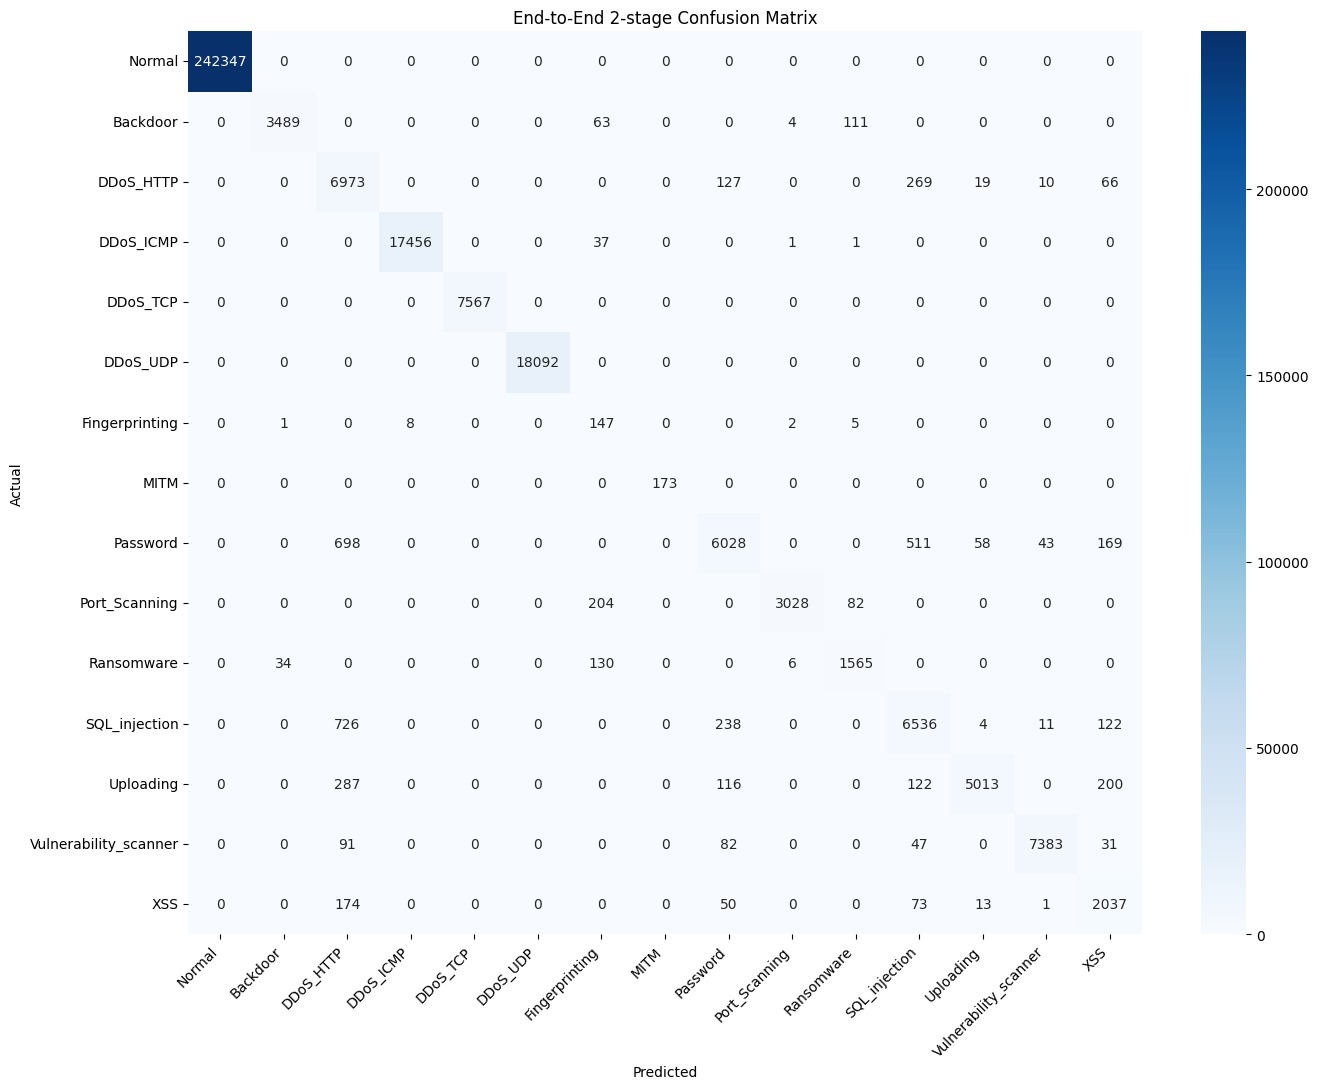


[End-to-End 1-stage]
  accuracy: 0.9844
  macro_precision: 0.8934
  macro_recall: 0.9272
  macro_f1: 0.8974

  [Class-wise Recall]
    Normal: 1.0000
    Backdoor: 0.9504
    DDoS_HTTP: 0.9318
    DDoS_ICMP: 0.9979
    DDoS_TCP: 1.0000
    DDoS_UDP: 1.0000
    Fingerprinting: 0.8712
    MITM: 1.0000
    Password: 0.7977
    Port_Scanning: 0.9128
    Ransomware: 0.8986
    SQL_injection: 0.8480
    Uploading: 0.8761
    Vulnerability_scanner: 0.9645
    XSS: 0.8599


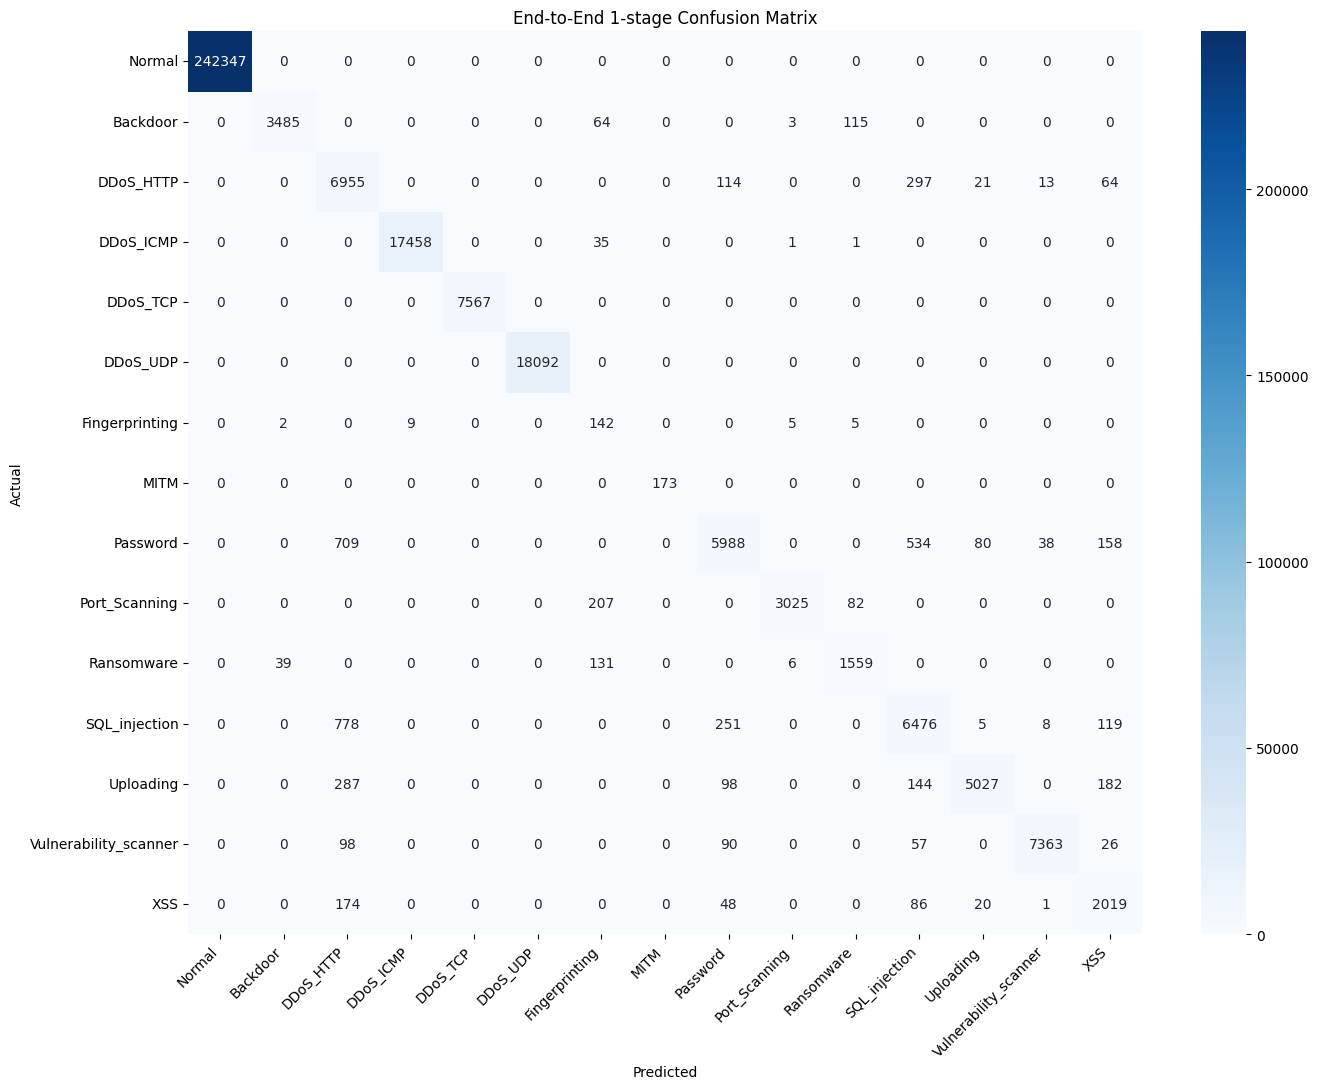


[End-to-End RF]
  accuracy: 0.9836
  macro_precision: 0.8944
  macro_recall: 0.9288
  macro_f1: 0.8942

  [Class-wise Recall]
    Normal: 1.0000
    Backdoor: 0.9190
    DDoS_HTTP: 0.9294
    DDoS_ICMP: 0.9991
    DDoS_TCP: 1.0000
    DDoS_UDP: 1.0000
    Fingerprinting: 0.9632
    MITM: 1.0000
    Password: 0.8559
    Port_Scanning: 0.9143
    Ransomware: 0.8836
    SQL_injection: 0.8053
    Uploading: 0.8674
    Vulnerability_scanner: 0.9418
    XSS: 0.8531


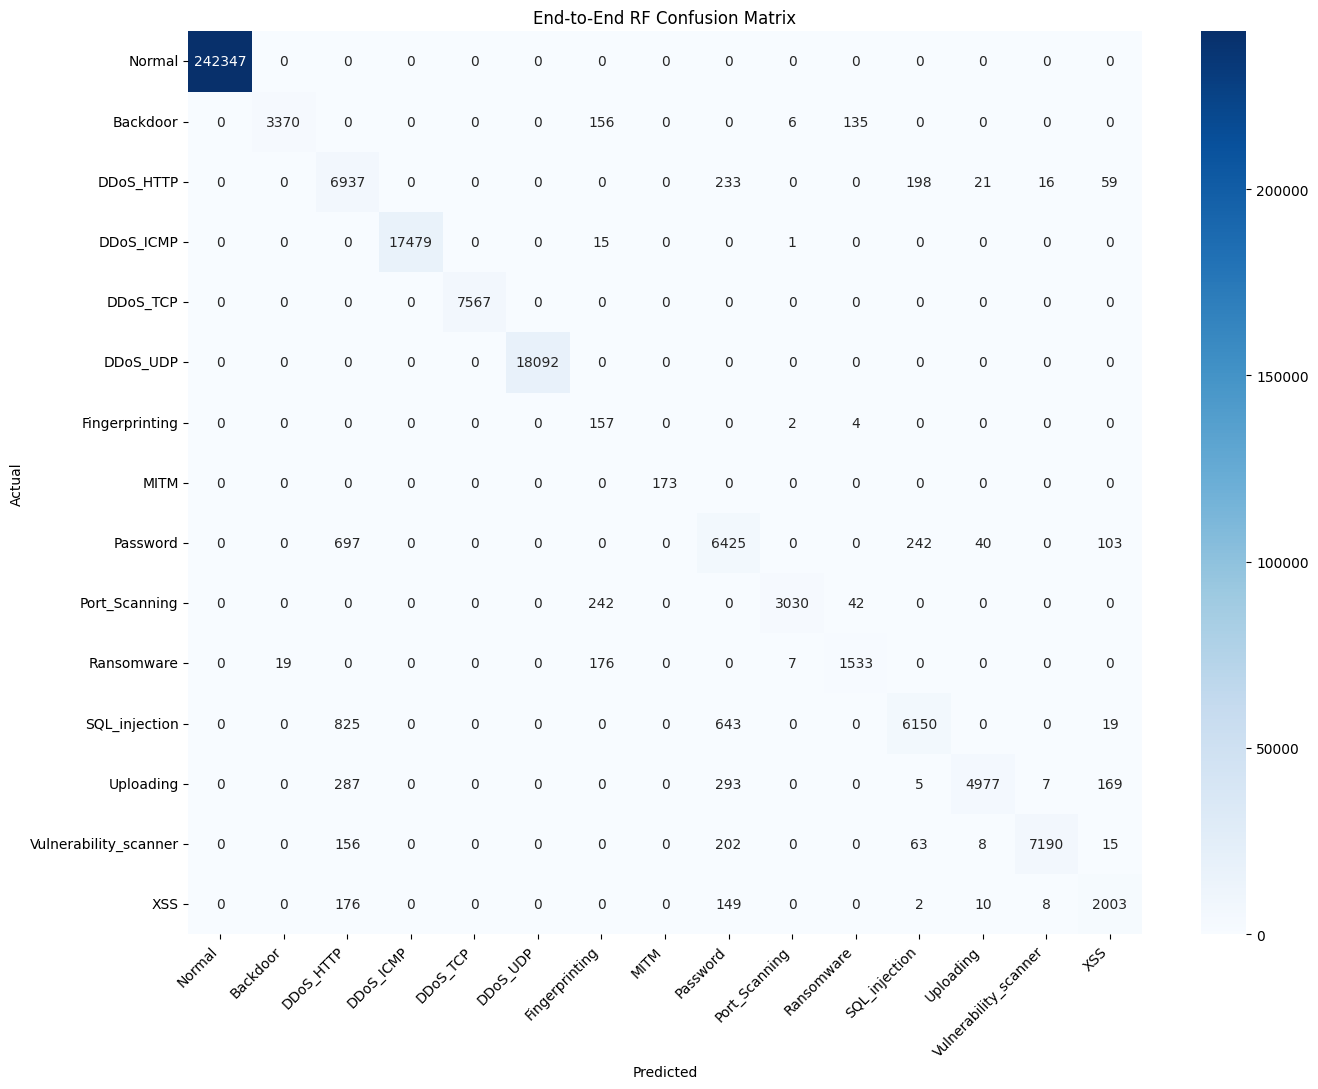


[End-to-End LR]
  accuracy: 0.9240
  macro_precision: 0.6423
  macro_recall: 0.6699
  macro_f1: 0.6054

  [Class-wise Recall]
    Normal: 0.9973
    Backdoor: 0.7175
    DDoS_HTTP: 0.8230
    DDoS_ICMP: 0.9475
    DDoS_TCP: 0.9052
    DDoS_UDP: 0.9991
    Fingerprinting: 0.9018
    MITM: 1.0000
    Password: 0.2327
    Port_Scanning: 0.7839
    Ransomware: 0.2640
    SQL_injection: 0.4167
    Uploading: 0.1520
    Vulnerability_scanner: 0.8139
    XSS: 0.0945


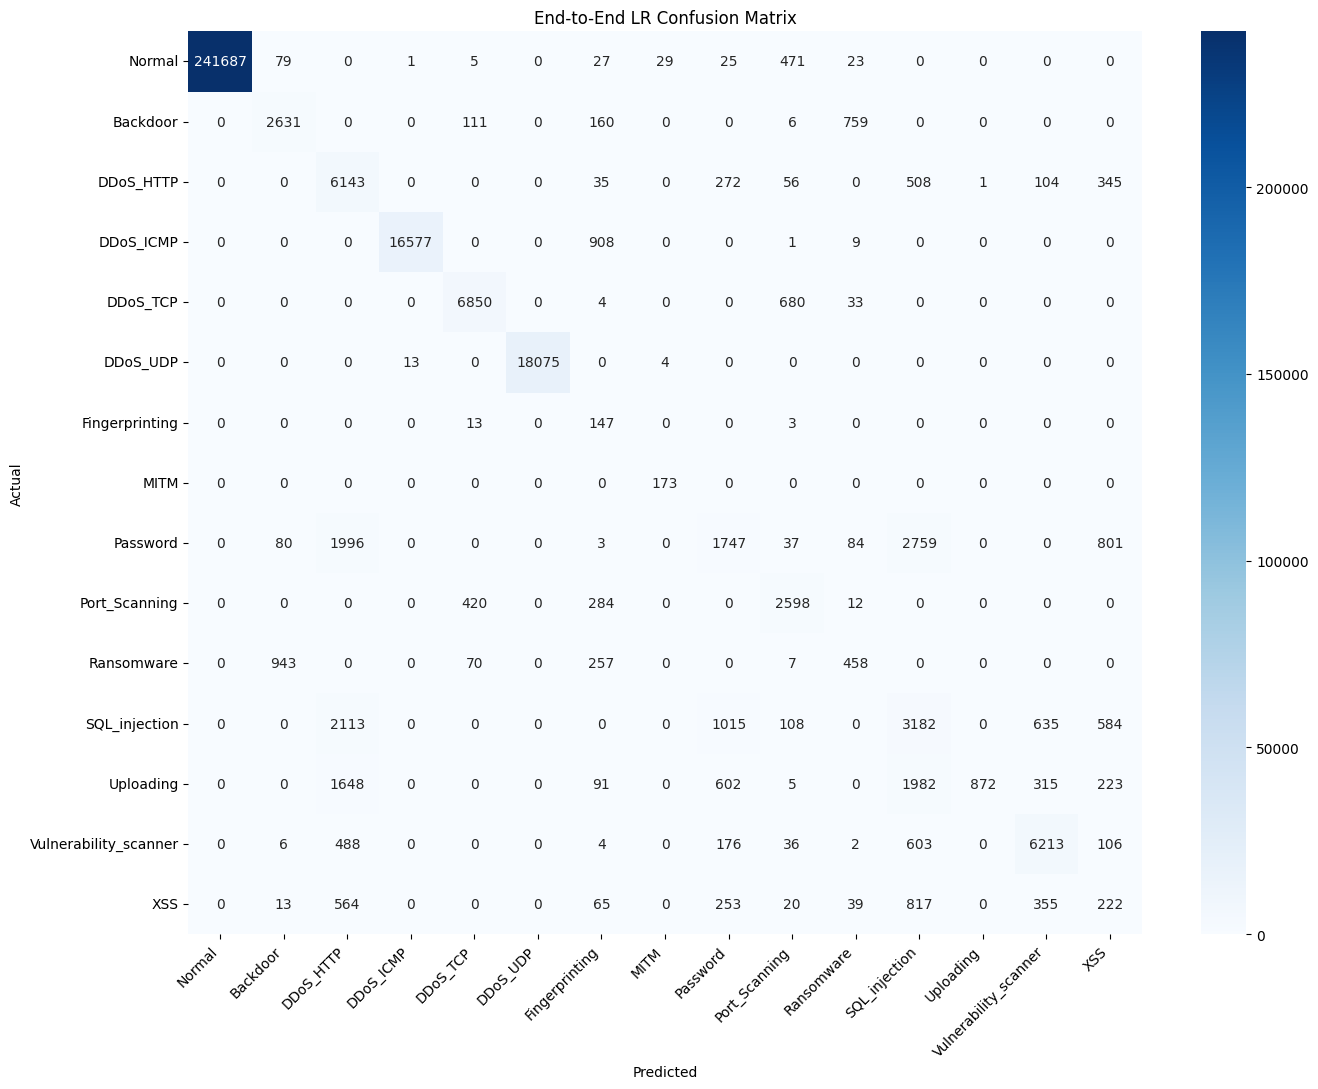


[End-to-End SMOTE]
  accuracy: 0.9849
  macro_precision: 0.9006
  macro_recall: 0.9326
  macro_f1: 0.9024

  [Class-wise Recall]
    Normal: 1.0000
    Backdoor: 0.9501
    DDoS_HTTP: 0.9382
    DDoS_ICMP: 0.9983
    DDoS_TCP: 1.0000
    DDoS_UDP: 1.0000
    Fingerprinting: 0.9387
    MITM: 1.0000
    Password: 0.8135
    Port_Scanning: 0.9086
    Ransomware: 0.9014
    SQL_injection: 0.8568
    Uploading: 0.8775
    Vulnerability_scanner: 0.9615
    XSS: 0.8445


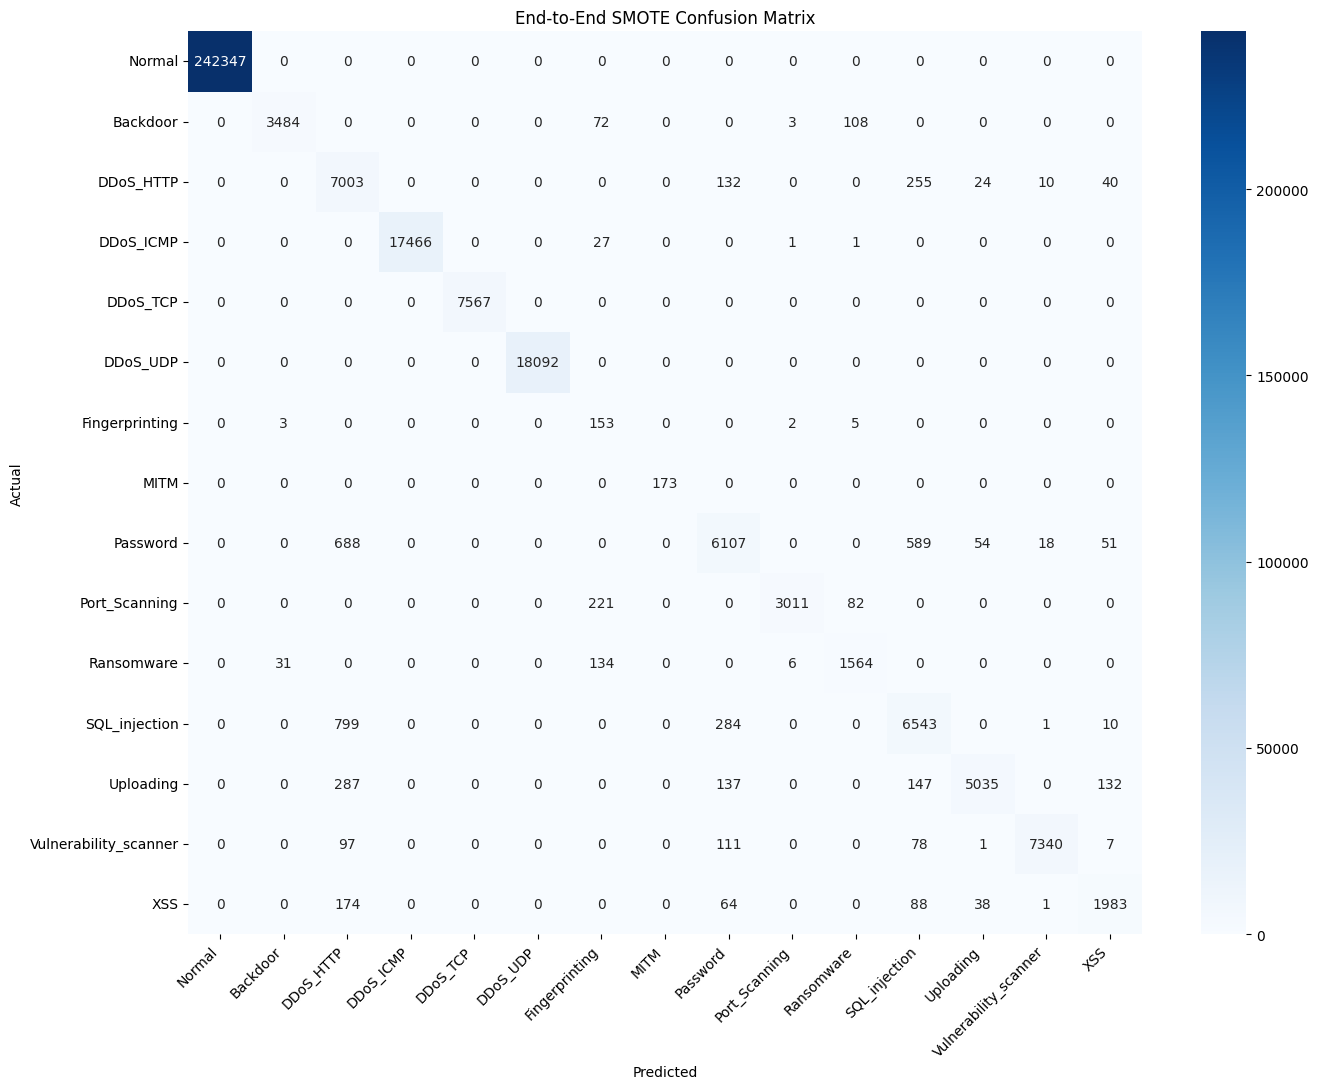

In [ ]:
def evaluate_end_to_end(final_pred, y_bin, atk_series, atk_map, suffix=""):
    names = ["Normal"] + sorted(atk_map.keys())
    actual = ["Normal" if y_bin[i] == 0 else str(atk_series.iloc[i]) for i in range(len(y_bin))]
    metrics = {
        "accuracy": accuracy_score(actual, final_pred),
        "macro_precision": precision_score(actual, final_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(actual, final_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(actual, final_pred, average="macro", zero_division=0),
    }
    print(f"\n[End-to-End {suffix}]")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")
    # class-wise recall
    pr = recall_score(actual, final_pred, average=None, labels=names, zero_division=0)
    print("\n  [Class-wise Recall]")
    for i, n in enumerate(names):
        if i < len(pr): print(f"    {n}: {pr[i]:.4f}")
    # confusion matrix
    cm = confusion_matrix(actual, final_pred, labels=names)
    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"End-to-End {suffix} Confusion Matrix")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()
    return metrics

# 예측 생성
pred_2stage = predict_two_stage(bin_model, mc_model, test_x, inverse_map)

single_pi = single_model.predict(test_x)
pred_1stage = ["Normal" if p == 0 else inverse_map.get(p - 1, "Unknown") for p in single_pi]

rf_pi = rf_model.predict(test_x_filled)
pred_rf = ["Normal" if p == 0 else inverse_map.get(p - 1, "Unknown") for p in rf_pi]

lr_pi = lr_model.predict(test_x_scaled)
pred_lr = ["Normal" if p == 0 else inverse_map.get(p - 1, "Unknown") for p in lr_pi]

pred_smote = predict_two_stage(bin_model_smote, mc_model_smote, test_x, inverse_map)

# 평가
results = {}
results["2-stage LightGBM"] = evaluate_end_to_end(pred_2stage, test_by, test_attack_series, attack_type_map, "2-stage")
results["1-stage LightGBM"] = evaluate_end_to_end(pred_1stage, test_by, test_attack_series, attack_type_map, "1-stage")
results["Random Forest"] = evaluate_end_to_end(pred_rf, test_by, test_attack_series, attack_type_map, "RF")
results["Logistic Regression"] = evaluate_end_to_end(pred_lr, test_by, test_attack_series, attack_type_map, "LR")
results["2-stage + SMOTE"] = evaluate_end_to_end(pred_smote, test_by, test_attack_series, attack_type_map, "SMOTE")

## 7. Binary ROC / PR Curve

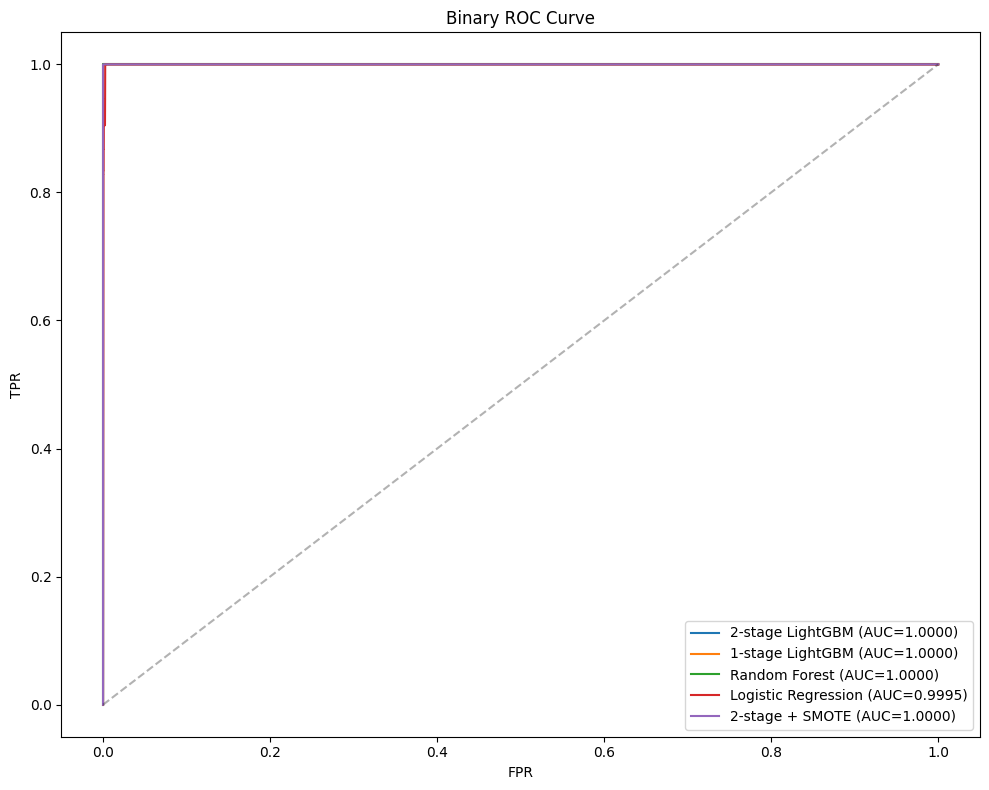

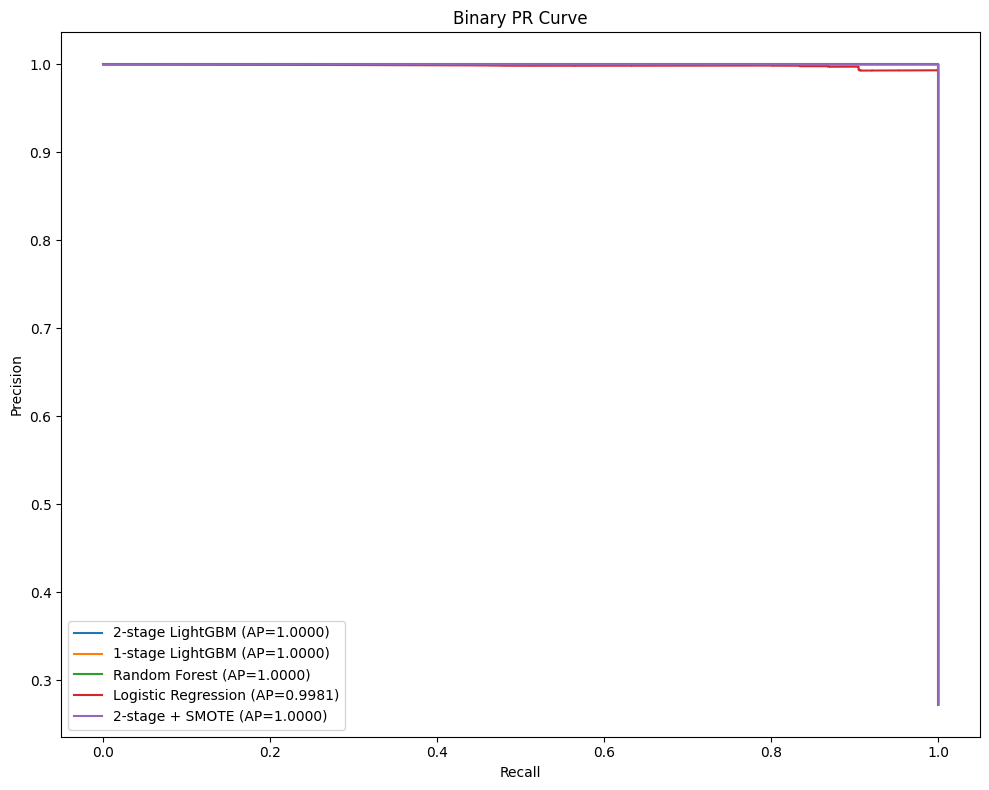

In [ ]:
# binary 확률 수집
models_proba = {
    "2-stage LightGBM": (test_by, bin_model.predict_proba(test_x)[:, 1]),
    "1-stage LightGBM": (test_by, 1.0 - single_model.predict_proba(test_x)[:, 0]),
    "Random Forest": (test_by, 1.0 - rf_model.predict_proba(test_x_filled)[:, 0]),
    "Logistic Regression": (test_by, 1.0 - lr_model.predict_proba(test_x_scaled)[:, 0]),
    "2-stage + SMOTE": (test_by, bin_model_smote.predict_proba(test_x)[:, 1]),
}

# ROC curve
fig, ax = plt.subplots(figsize=(10, 8))
auc_scores = {}
for name, (yt, yp) in models_proba.items():
    fpr, tpr, _ = roc_curve(yt, yp)
    auc_val = roc_auc_score(yt, yp)
    auc_scores[name] = auc_val
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")
ax.plot([0,1],[0,1],"k--",alpha=0.3)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("Binary ROC Curve")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

# PR curve
fig, ax = plt.subplots(figsize=(10, 8))
ap_scores = {}
for name, (yt, yp) in models_proba.items():
    prec, rec, _ = precision_recall_curve(yt, yp)
    ap_val = average_precision_score(yt, yp)
    ap_scores[name] = ap_val
    ax.plot(rec, prec, label=f"{name} (AP={ap_val:.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("Binary PR Curve")
ax.legend(loc="lower left"); plt.tight_layout(); plt.show()

# 결과에 추가
for name in results:
    if name in auc_scores: results[name]["roc_auc"] = auc_scores[name]
    if name in ap_scores: results[name]["ap"] = ap_scores[name]

## 8. McNemar's test (1-stage vs 2-stage)

In [ ]:
test_true = ["Normal" if test_by[i] == 0 else str(test_attack_series.iloc[i]) for i in range(len(test_by))]
ca = (np.array(pred_2stage) == np.array(test_true)).astype(int)
cb = (np.array(pred_1stage) == np.array(test_true)).astype(int)

both_ok = ((ca==1)&(cb==1)).sum()
a_only = ((ca==1)&(cb==0)).sum()
b_only = ((ca==0)&(cb==1)).sum()
both_bad = ((ca==0)&(cb==0)).sum()

print("[McNemar's test: 2-stage vs 1-stage]")
print(f"  둘 다 맞음: {both_ok}")
print(f"  2-stage만 맞음: {a_only}")
print(f"  1-stage만 맞음: {b_only}")
print(f"  둘 다 틀림: {both_bad}")

b, c = a_only, b_only
if b + c > 0:
    chi2_stat = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - chi2.cdf(chi2_stat, df=1)
    print(f"  chi2 = {chi2_stat:.4f}, p-value = {p_value:.6f}")
    print("  → 유의한 차이 있음" if p_value < 0.05 else "  → 유의한 차이 없음")
else:
    print("  → 차이 없음 (b + c = 0)")

[McNemar's test: 2-stage vs 1-stage]
  둘 다 맞음: 327328
  2-stage만 맞음: 506
  1-stage만 맞음: 348
  둘 다 틀림: 4699
  chi2 = 28.8630, p-value = 0.000000
  → 유의한 차이 있음


## 9. 추론 시간 측정

In [ ]:
""" 5개 모델 각각에 대해 같은 test set으로 시간 측정하고, 결과를 results에 추가해서 비교 테이블에 들어가게 합니다. """

def measure_latency(predict_fn, X, name, warmup=3, repeats=10, normal_mask=None):
    n = len(X)
    for _ in range(warmup): predict_fn(X)
    times = []
    for _ in range(repeats):
        s = time.perf_counter()
        predict_fn(X)
        times.append((time.perf_counter() - s) * 1000)
    arr = np.array(times)
    r = {"total_mean_ms": arr.mean(), "total_std_ms": arr.std(),
         "per_sample_us": (arr.mean()/n)*1000, "p95_ms": np.percentile(arr, 95)}
    print(f"\n[{name}] {r['total_mean_ms']:.1f}±{r['total_std_ms']:.1f}ms, "
          f"건당 {r['per_sample_us']:.2f}μs, p95={r['p95_ms']:.1f}ms")
    if normal_mask is not None:
        for label, mask in [("Normal", normal_mask), ("Attack", ~normal_mask)]:
            sub = X[mask]
            if len(sub) > 0:
                st = []
                for _ in range(repeats):
                    s = time.perf_counter(); predict_fn(sub)
                    st.append((time.perf_counter()-s)*1000)
                r[f"{label.lower()}_us"] = (np.mean(st)/len(sub))*1000
                print(f"  {label} 건당: {r[f'{label.lower()}_us']:.2f}μs")
    return r

nm = test_by == 0
lat = {}
lat["2-stage LightGBM"] = measure_latency(lambda X: predict_two_stage(bin_model, mc_model, X, inverse_map), test_x, "2-stage", normal_mask=nm)
lat["1-stage LightGBM"] = measure_latency(lambda X: single_model.predict(X), test_x, "1-stage", normal_mask=nm)
lat["Random Forest"] = measure_latency(lambda X: rf_model.predict(X.fillna(0)), test_x, "RF", normal_mask=nm)
lat["Logistic Regression"] = measure_latency(lambda X: lr_model.predict(test_x_scaled), test_x, "LR", normal_mask=nm)
lat["2-stage + SMOTE"] = measure_latency(lambda X: predict_two_stage(bin_model_smote, mc_model_smote, X, inverse_map), test_x, "SMOTE", normal_mask=nm)

for name, l in lat.items():
    if name in results:
        results[name]["latency_ms"] = l["total_mean_ms"]
        results[name]["per_sample_us"] = l["per_sample_us"]


[2-stage] 3658.2±174.6ms, 건당 10.99μs, p95=3968.1ms
  Normal 건당: 2.12μs
  Attack 건당: 33.82μs

[1-stage] 11155.2±149.3ms, 건당 33.51μs, p95=11362.8ms
  Normal 건당: 32.24μs
  Attack 건당: 35.37μs

[RF] 2125.3±18.4ms, 건당 6.38μs, p95=2153.0ms
  Normal 건당: 5.70μs
  Attack 건당: 6.52μs

[LR] 96.8±16.8ms, 건당 0.29μs, p95=123.7ms
  Normal 건당: 0.43μs
  Attack 건당: 1.09μs

[SMOTE] 6801.1±292.9ms, 건당 20.43μs, p95=7191.1ms
  Normal 건당: 4.10μs
  Attack 건당: 64.34μs


## 10. SHAP 분석 (메인 모델: 2-stage LightGBM)

[Binary SHAP Summary]


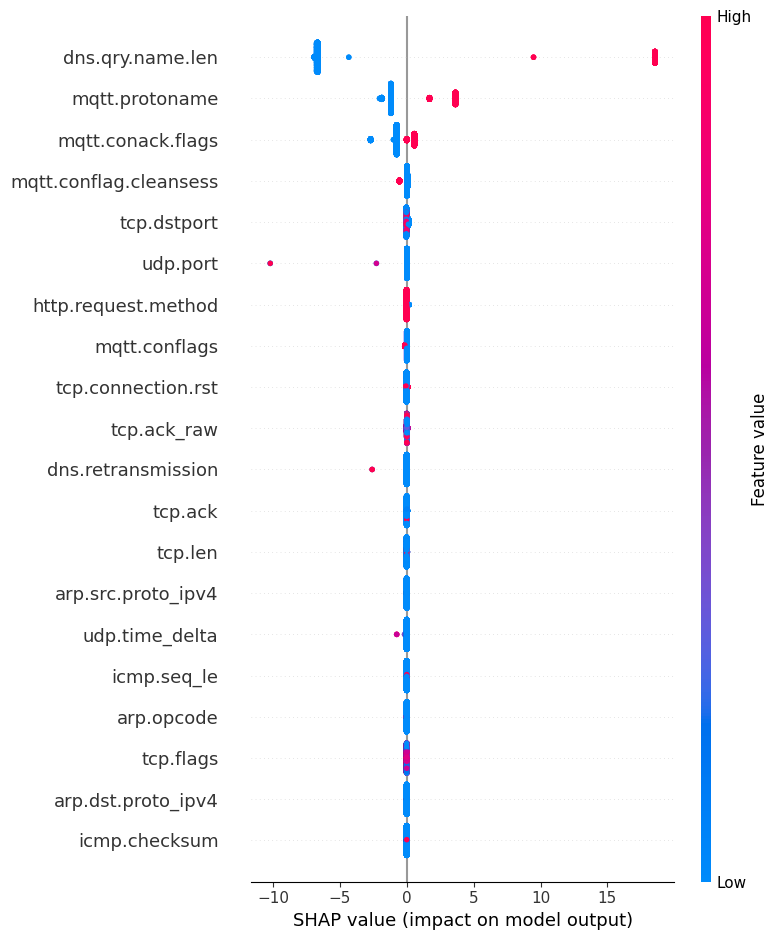

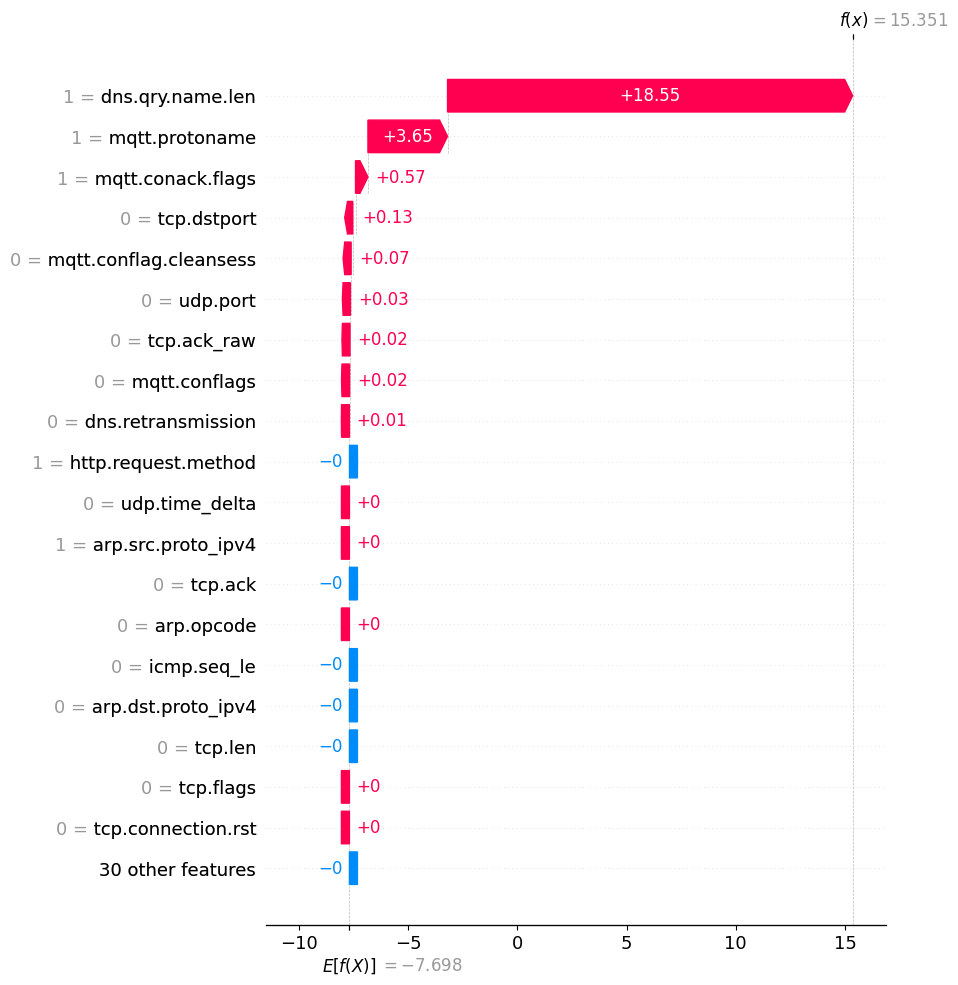

[Binary SHAP Dependence]


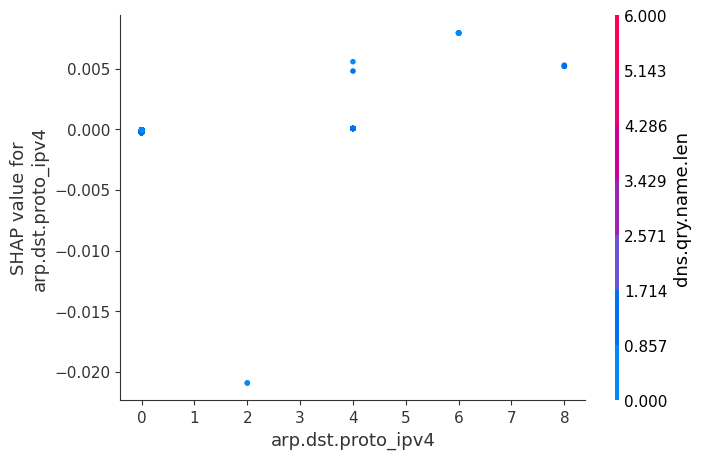

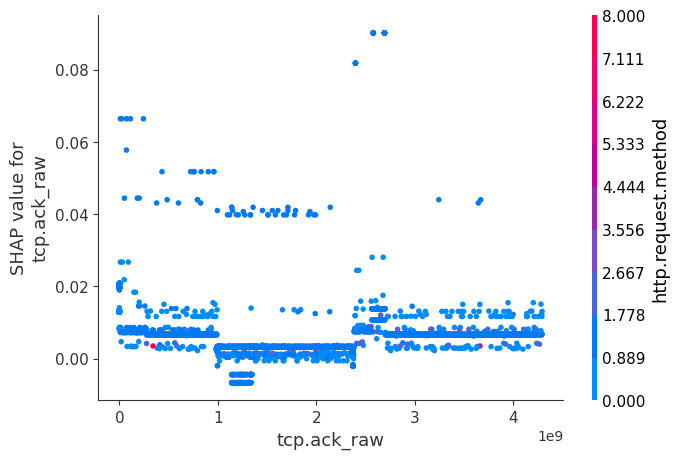

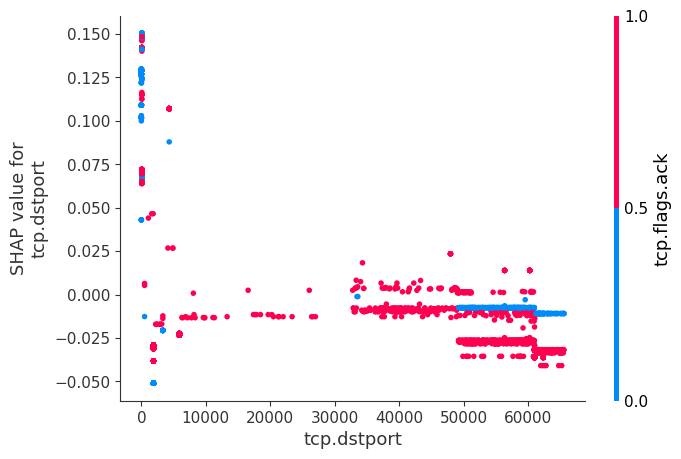

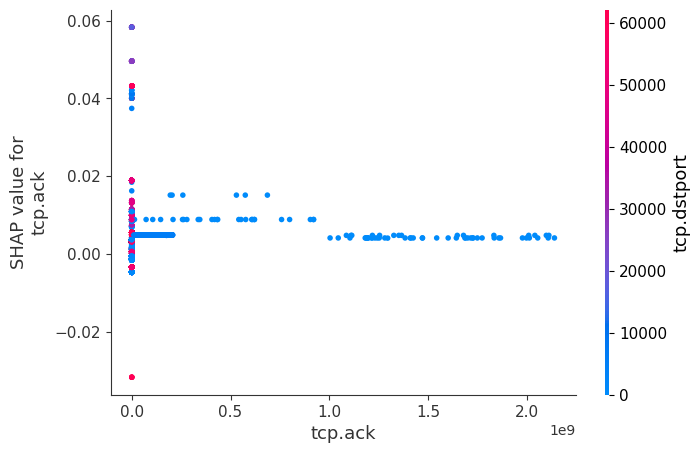

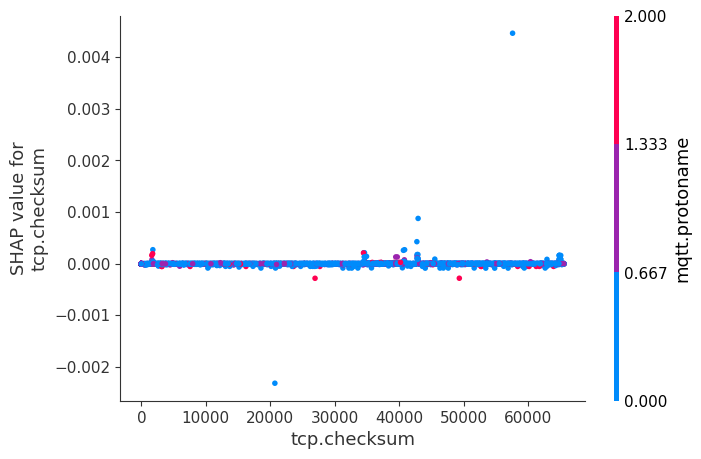

[Multiclass SHAP Summary]


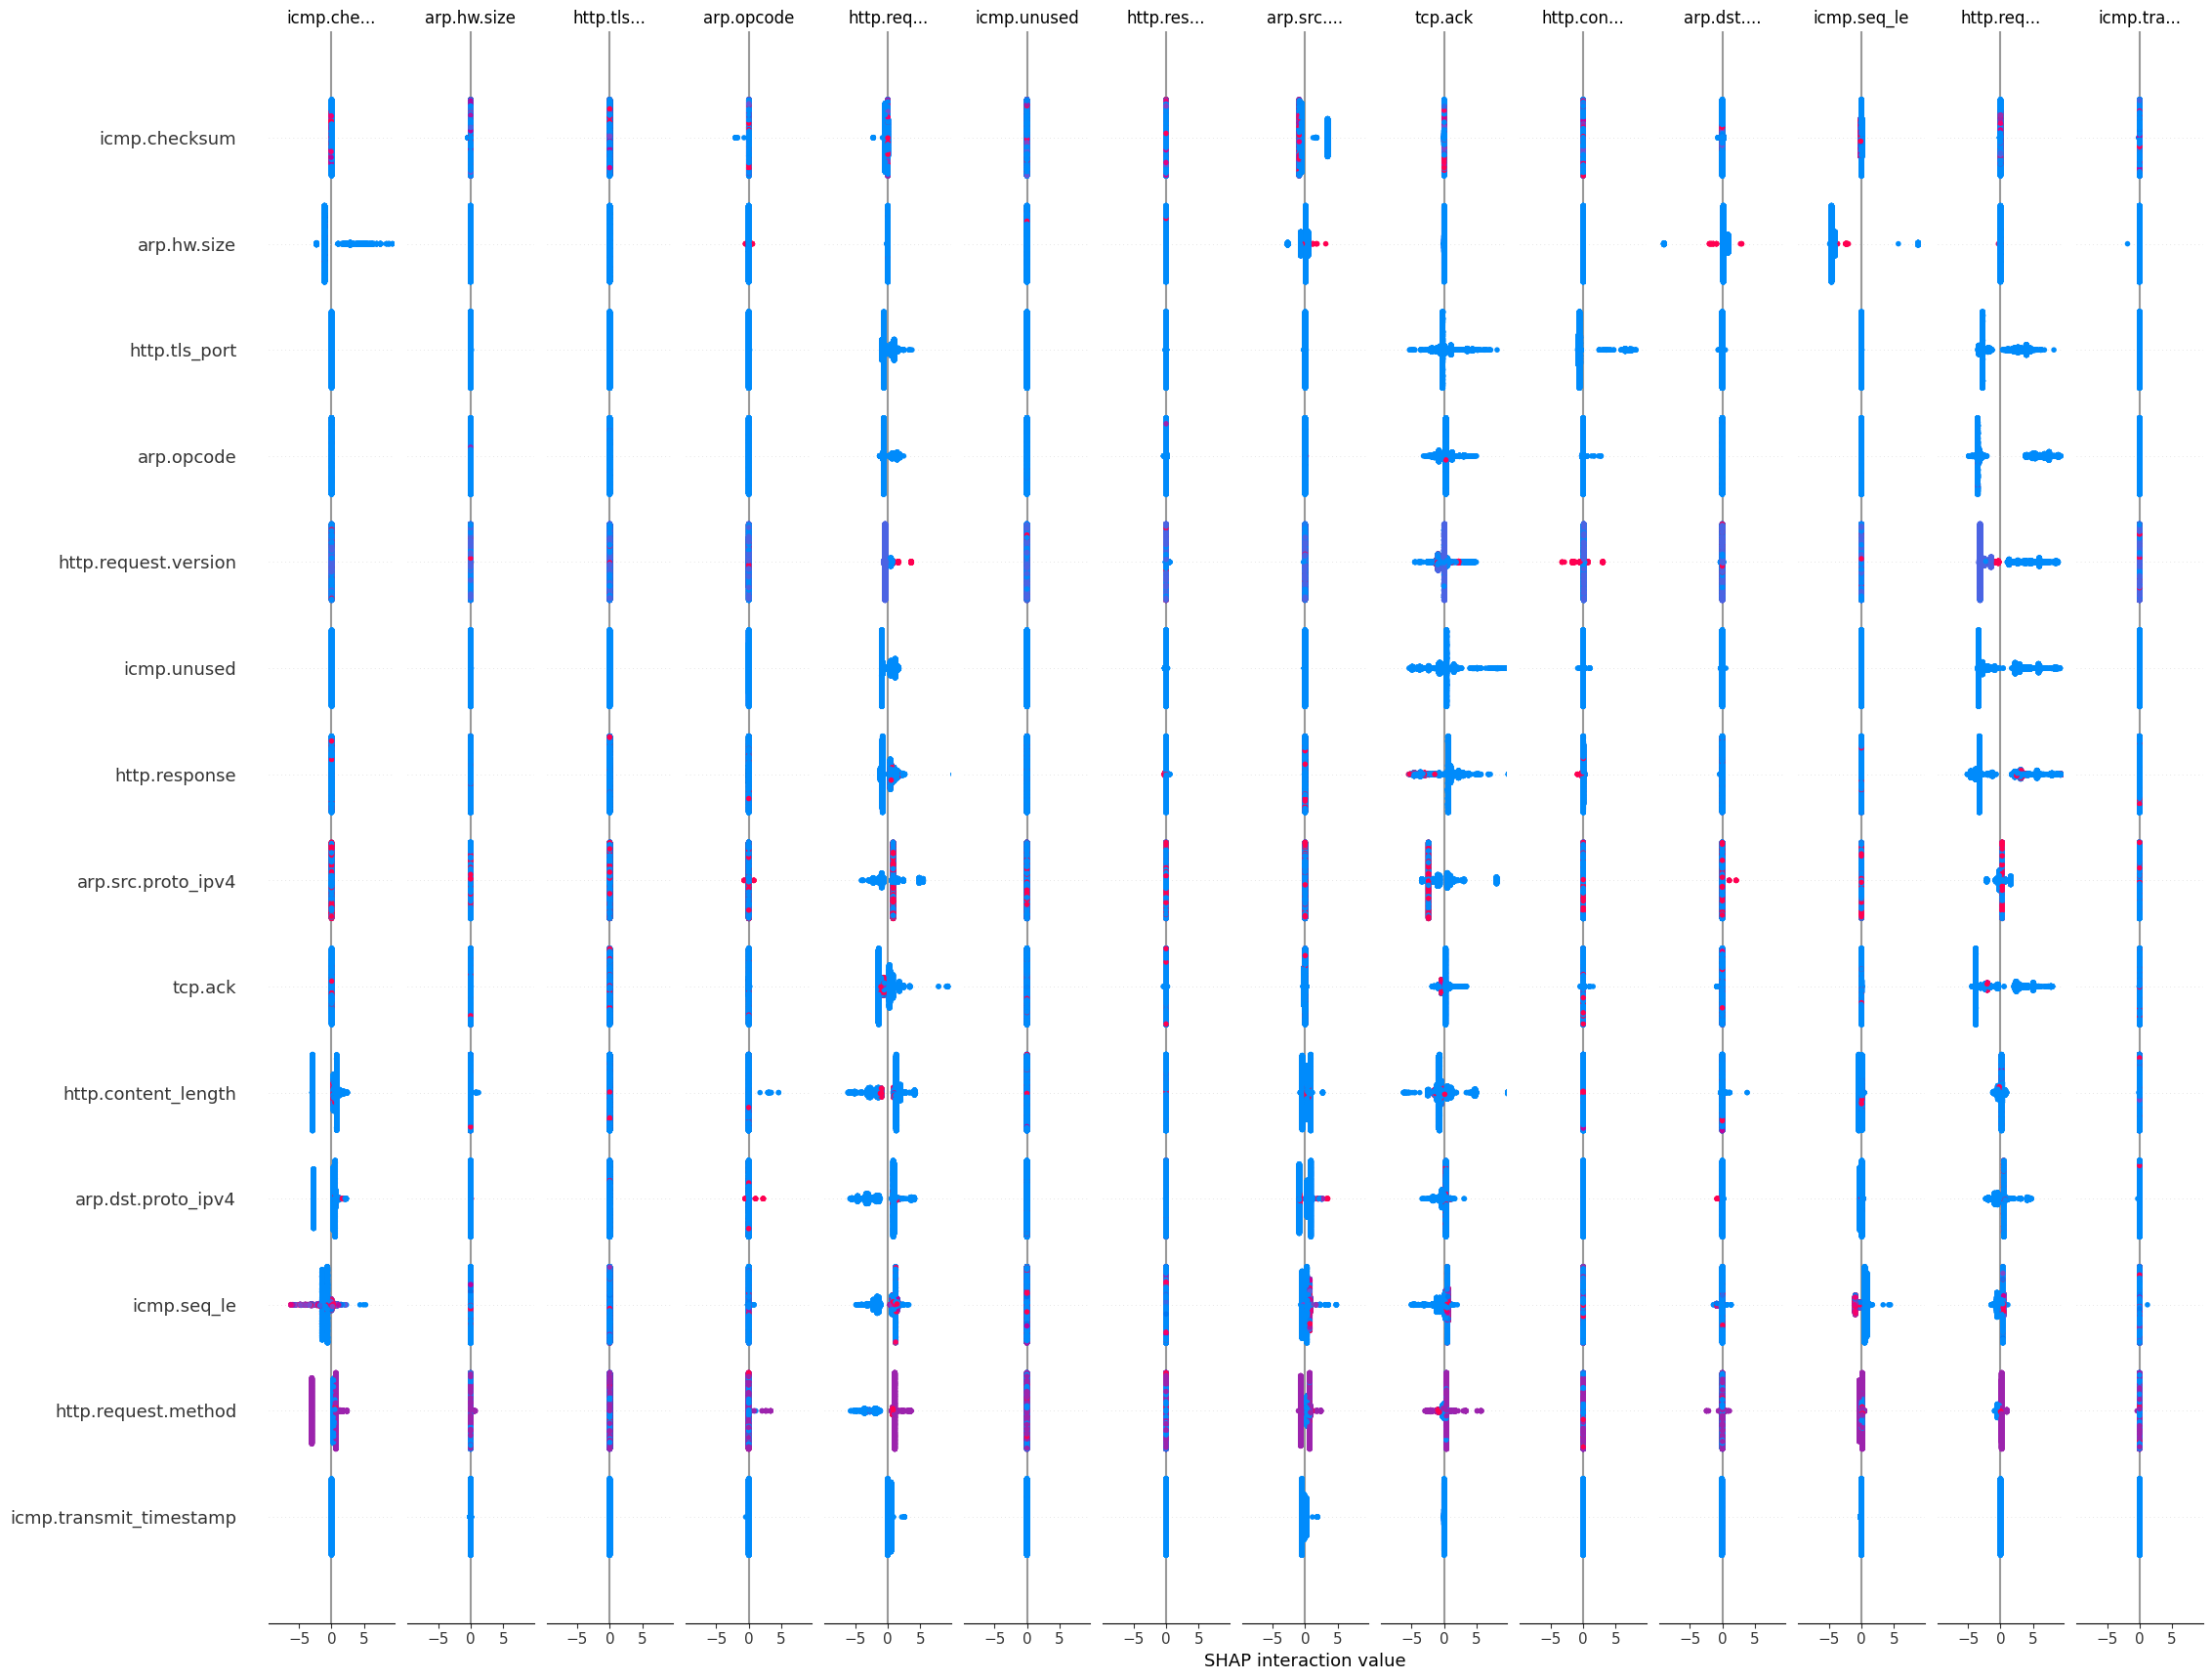

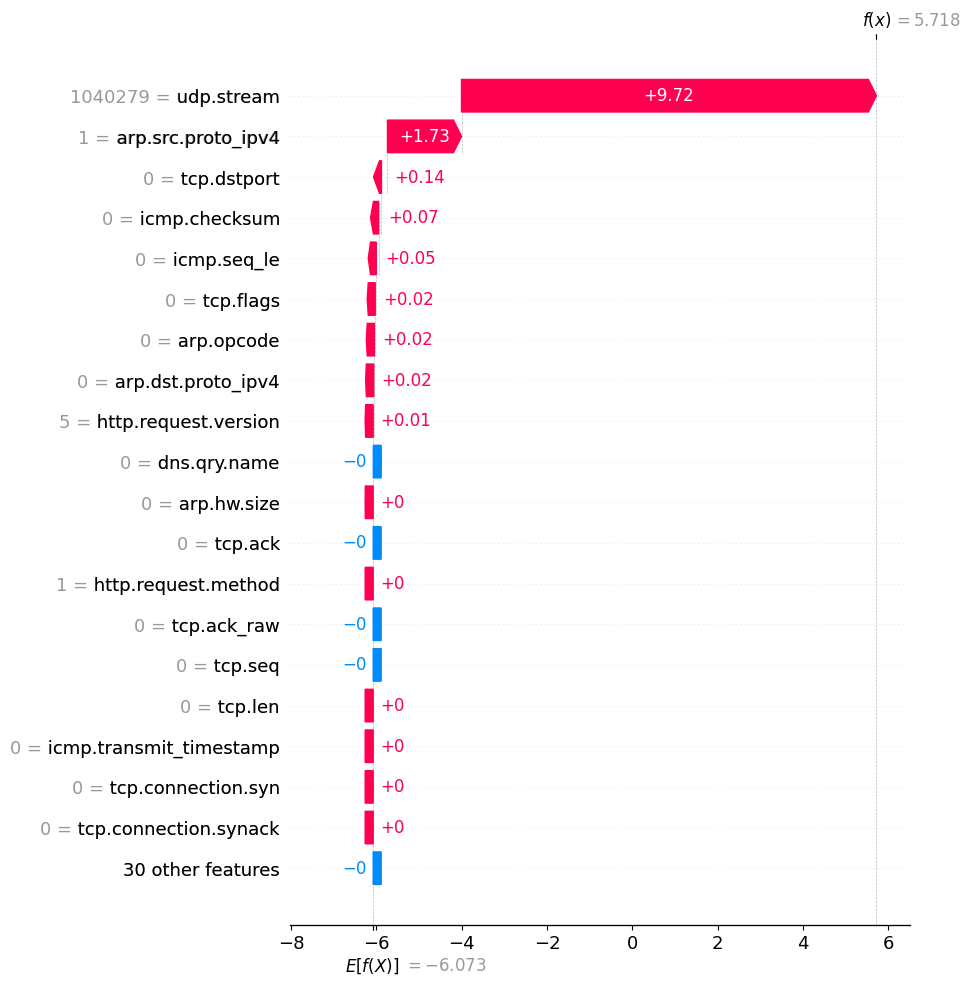

[SHAP 분석 완료]


In [ ]:
"""
메인 모델(2-stage LightGBM)만 대상으로, binary와 multiclass 각각 분석합니다.

Binary SHAP:

validation set에서 5000건 샘플링
TreeExplainer로 각 샘플의 각 피처가 예측에 얼마나 기여했는지 계산
Summary plot → 전체 5000건에서 피처별 영향력 분포를 한 그래프로 보여줌
Waterfall plot → 공격으로 판정된 샘플 1개를 골라서 "이 샘플이 왜 공격으로 판정됐는지" 피처별 기여도를 보여줌
Dependence plot → 상위 5개 피처 각각에 대해 "이 피처 값이 변할 때 예측이 어떻게 바뀌는지" 산점도로 보여줌
Multiclass SHAP:

공격 데이터 validation set에서 5000건 샘플링
같은 방식으로 summary plot + waterfall plot 생성
 """

shap_sample = val_x.sample(n=min(5000, len(val_x)), random_state=RANDOM_STATE)

# Binary SHAP
print("[Binary SHAP Summary]")
bex = shap.TreeExplainer(bin_model)
bsv = bex.shap_values(shap_sample)
if isinstance(bsv, list): bsv = bsv[1]
shap.summary_plot(bsv, shap_sample, show=True, max_display=20)

# Binary Waterfall
atk_idx = np.where(bin_model.predict(val_x) == 1)[0]
if len(atk_idx) > 0:
    row = val_x.iloc[[atk_idx[0]]]
    sv1 = bex.shap_values(row)
    if isinstance(sv1, list): sv1 = sv1[1]
    bv = bex.expected_value if not isinstance(bex.expected_value, list) else bex.expected_value[1]
    exp = shap.Explanation(values=sv1[0], base_values=bv, data=row.iloc[0].values, feature_names=row.columns.tolist())
    shap.plots.waterfall(exp, show=True, max_display=20)

# Binary Dependence (top 5)
print("[Binary SHAP Dependence]")
imp = bin_model.feature_importances_
for fi in np.argsort(imp)[::-1][:5]:
    shap.dependence_plot(fi, bsv, shap_sample, show=True)

# Multiclass SHAP
print("[Multiclass SHAP Summary]")
mc_sample = val_mc_x.sample(n=min(5000, len(val_mc_x)), random_state=RANDOM_STATE)
mex = shap.TreeExplainer(mc_model)
msv = mex.shap_values(mc_sample)
shap.summary_plot(msv, mc_sample, show=True, max_display=20, class_names=list(attack_type_map.keys()))

# Multiclass Waterfall
if len(val_mc_x) > 0:
    row = val_mc_x.iloc[[0]]
    pc = int(mc_model.predict(row)[0])
    sv1 = mex.shap_values(row)
    if isinstance(sv1, list):
        svc = np.array(sv1[pc]).flatten()
        ev = mex.expected_value[pc]
    elif sv1.ndim == 3:
        svc = sv1[0, :, pc]; ev = mex.expected_value[pc]
    else:
        svc = sv1.flatten(); ev = mex.expected_value
    pn = list(attack_type_map.keys())[pc] if pc < len(attack_type_map) else "Unknown"
    exp = shap.Explanation(values=svc, base_values=float(ev), data=row.iloc[0].values, feature_names=row.columns.tolist())
    shap.plots.waterfall(exp, show=True, max_display=20)
print("[SHAP 분석 완료]")

## 11. 누수 검증 Ablation Test

In [ ]:
""" binary 모델이 accuracy 1.0 (100%)이 나와서 누수 검증이 필요해 보여서 해보았습니다.
진행 순서:
먼저 모든 피처를 다 쓴 상태로 binary 모델 학습 → baseline F1 기록

feature importance 1위 피처를 제거 → 다시 학습 → F1 기록 → 차이 계산

2위 피처 제거 → 다시 학습 → F1 기록 → 차이 계산

3~5위도 같은 방식
 """
feature_names = preprocess_info["feature_columns"]
base_m = train_binary_lgbm(train_x, train_by, val_x, val_by)
base_pred = base_m.predict(val_x)
base_f1 = f1_score(val_by, base_pred, average="macro", zero_division=0)
print(f"[Ablation] Baseline Macro F1: {base_f1:.4f}")

imp = base_m.feature_importances_
rows = []
for rank, fi in enumerate(np.argsort(imp)[::-1][:5]):
    fname = feature_names[fi]
    tr = train_x.drop(columns=[fname], errors="ignore")
    va = val_x.drop(columns=[fname], errors="ignore")
    m = train_binary_lgbm(tr, train_by, va, val_by)
    p = m.predict(va)
    nf1 = f1_score(val_by, p, average="macro", zero_division=0)
    delta = nf1 - base_f1
    rows.append({"rank": rank+1, "feature": fname, "baseline_f1": base_f1, "ablated_f1": nf1, "delta": delta})
    print(f"  #{rank+1} {fname}: {nf1:.4f} (delta={delta:+.4f})")

ablation_df = pd.DataFrame(rows)
display(ablation_df)

Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.0325297
[100]	valid_0's binary_logloss: 0.00261822
[150]	valid_0's binary_logloss: 0.000214696
[200]	valid_0's binary_logloss: 1.76211e-05
[250]	valid_0's binary_logloss: 1.44641e-06
[300]	valid_0's binary_logloss: 1.19106e-07
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 1.19106e-07
  [binary] best iter: 300
[Ablation] Baseline Macro F1: 1.0000
Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.0325297
[100]	valid_0's binary_logloss: 0.0026182
[150]	valid_0's binary_logloss: 0.000214577
[200]	valid_0's binary_logloss: 1.76161e-05
[250]	valid_0's binary_logloss: 1.446e-06
[300]	valid_0's binary_logloss: 1.19053e-07
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 1.19053e-07
  [binary] best iter: 300
  #1 arp.dst.proto_ipv4: 1.0000 (delta=+0.0000)
Training until validation scores don't i

,rank,feature,baseline_f1,ablated_f1,delta
0,1,arp.dst.proto_ipv4,1.0,1.0,0.0
1,2,tcp.ack_raw,1.0,1.0,0.0
2,3,tcp.dstport,1.0,1.0,0.0
3,4,tcp.ack,1.0,1.0,0.0
4,5,tcp.checksum,1.0,1.0,0.0


## 11-1. Train/Test Exact Duplicate 검사

In [ ]:
""" train과 test에 완전히 동일한 행이 있는지 확인합니다.
중복이 많으면 모델이 '일반화'한 게 아니라 이미 본 데이터를 다시 맞춘 것일 수 있습니다.
"""
# train/test feature를 문자열로 변환해서 비교
train_keys = set(train_x.fillna(-999).astype(str).apply(lambda r: '|'.join(r), axis=1))
test_keys = test_x.fillna(-999).astype(str).apply(lambda r: '|'.join(r), axis=1)
dup_mask = test_keys.isin(train_keys)
n_dup = dup_mask.sum()
print(f"[Duplicate 검사]")
print(f"  test set 중 train과 완전 동일한 행: {n_dup} / {len(test_keys)} ({n_dup/len(test_keys)*100:.2f}%)")
if n_dup > 0:
    print(f"  → 중복 행이 존재합니다. 성능이 과대평가되었을 가능성이 있습니다.")
else:
    print(f"  → 중복 없음. train/test 분리가 깨끗합니다.")

[Duplicate 검사]
  test set 중 train과 완전 동일한 행: 56448 / 332881 (16.96%)
  → 중복 행이 존재합니다. 성능이 과대평가되었을 가능성이 있습니다.


## 11-2. Single-Feature Baseline (데이터셋 난이도 확인)

In [ ]:
""" 단일 feature 하나만으로 binary 분류했을 때 성능이 어느 정도인지 확인합니다.
만약 feature 1개만으로도 F1이 매우 높다면, 데이터셋 자체가 쉬운 것이지 모델이 대단한 게 아닙니다.
이는 데이터셋의 artifact/shortcut 가능성을 보여주는 증거가 됩니다.
"""
# importance 상위 5개 feature로 각각 단독 binary 분류
imp = bin_model.feature_importances_
top5_idx = np.argsort(imp)[::-1][:5]
single_rows = []

for fi in top5_idx:
    fname = feature_names[fi]
    tr_single = train_x[[fname]].fillna(0)
    va_single = val_x[[fname]].fillna(0)
    m = lgb.LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    m.fit(tr_single, train_by, eval_set=[(va_single, val_by)],
          callbacks=[lgb.early_stopping(10, verbose=False), lgb.log_evaluation(0)])
    p = m.predict(va_single)
    sf1 = f1_score(val_by, p, average="macro", zero_division=0)
    single_rows.append({"feature": fname, "binary_macro_f1": sf1})
    print(f"  {fname} 단독 → Binary Macro F1: {sf1:.4f}")

single_df = pd.DataFrame(single_rows)
display(single_df)

  arp.dst.proto_ipv4 단독 → Binary Macro F1: 0.4477
  tcp.ack_raw 단독 → Binary Macro F1: 0.6751
  tcp.dstport 단독 → Binary Macro F1: 0.9596
  tcp.ack 단독 → Binary Macro F1: 0.8011
  tcp.checksum 단독 → Binary Macro F1: 0.7353


,feature,binary_macro_f1
0,arp.dst.proto_ipv4,0.447665
1,tcp.ack_raw,0.675109
2,tcp.dstport,0.959570
3,tcp.ack,0.801071
4,tcp.checksum,0.735280


## 11-3. Feature-Group Ablation (Shortcut 의존도 분석)

In [ ]:
""" 비슷한 정보를 가진 feature들을 그룹으로 묶어서 한꺼번에 제거합니다.
single-feature ablation에서는 중복 feature 때문에 하나 빼도 성능이 안 떨어졌지만,
그룹 단위로 빼면 진짜 의존도가 드러납니다.
"""
# feature 그룹 정의 (실제 존재하는 컬럼만 필터링)
all_cols = set(feature_names)
groups = {
    "port 계열": [c for c in all_cols if "port" in c.lower()],
    "tcp header 계열": [c for c in all_cols if c.startswith("tcp.")],
    "dns 계열": [c for c in all_cols if c.startswith("dns.")],
    "mqtt 계열": [c for c in all_cols if c.startswith("mqtt.")],
    "http 계열": [c for c in all_cols if c.startswith("http.")],
    "packet length 계열": [c for c in all_cols if "len" in c.lower() or "length" in c.lower()],
}

# baseline
base_pred = bin_model.predict(val_x)
base_f1 = f1_score(val_by, base_pred, average="macro", zero_division=0)
print(f"[Feature-Group Ablation] Baseline Binary Macro F1: {base_f1:.4f}\n")

group_rows = []
for gname, cols in groups.items():
    cols = [c for c in cols if c in feature_names]  # 실제 존재하는 것만
    if not cols:
        print(f"  {gname}: 해당 컬럼 없음, 건너뜀")
        continue
    tr = train_x.drop(columns=cols, errors="ignore")
    va = val_x.drop(columns=cols, errors="ignore")
    m = train_binary_lgbm(tr, train_by, va, val_by)
    p = m.predict(va)
    gf1 = f1_score(val_by, p, average="macro", zero_division=0)
    delta = gf1 - base_f1
    group_rows.append({"group": gname, "removed_count": len(cols), "ablated_f1": gf1, "delta": delta})
    print(f"  {gname} ({len(cols)}개 제거): F1={gf1:.4f} (delta={delta:+.4f})")

group_df = pd.DataFrame(group_rows)
display(group_df)

[Feature-Group Ablation] Baseline Binary Macro F1: 1.0000

Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.0325759
[100]	valid_0's binary_logloss: 0.00262616
[150]	valid_0's binary_logloss: 0.000215228
[200]	valid_0's binary_logloss: 1.76648e-05
[250]	valid_0's binary_logloss: 1.45e-06
[300]	valid_0's binary_logloss: 1.19359e-07
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 1.19359e-07
  [binary] best iter: 300
  port 계열 (3개 제거): F1=1.0000 (delta=+0.0000)
Training until validation scores don't improve for 10 rounds
[50]	valid_0's binary_logloss: 0.0325297
[100]	valid_0's binary_logloss: 0.0026182
[150]	valid_0's binary_logloss: 0.000214577
[200]	valid_0's binary_logloss: 1.83602e-05
[250]	valid_0's binary_logloss: 1.50708e-06
[300]	valid_0's binary_logloss: 1.24049e-07
Did not meet early stopping. Best iteration is:
[300]	valid_0's binary_logloss: 1.24049e-07
  [binary] best iter: 300
  tcp header 계열 (12개 제

,group,removed_count,ablated_f1,delta
0,port 계열,3,1.0,0.0
1,tcp header 계열,12,1.0,0.0
2,dns 계열,7,1.0,0.0
3,mqtt 계열,11,1.0,0.0
4,http 계열,5,1.0,0.0
5,packet length 계열,7,1.0,0.0


## 12. 모델 비교 종합 테이블

In [ ]:
""" 앞에서 측정한 모든 결과를 하나의 표로 정리하는 셀

모델	          Accuracy	Macro P	Macro R	Macro F1	ROC-AUC	AP	Latency(ms)
2-stage LightGBM	...	    ...	      ...	  ...	      ...  ...	   ...
1-stage LightGBM	...	    ...	      ...	  ...	      ...  ...	   ...
Random Forest	    ...	    ...	      ...	  ...	      ...  ...	   ...
Logistic Regression	...	    ...	      ...	  ...	      ...  ...	   ...
2-stage + SMOTE	    ...	    ...	      ...	  ...	      ...  ...	   ...
"""
comparison = pd.DataFrame(results).T
comparison.index.name = "Model"
comparison.to_csv(OUTPUTS_DIR / "model_comparison.csv")
display(comparison.style.format("{:.4f}"))

print(f"\n환경: Python {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"LightGBM: {lgb.__version__}")
print("\n전체 실험 완료!")

,accuracy,macro_precision,macro_recall,macro_f1,roc_auc,ap,latency_ms,per_sample_us
Model,,,,,,,,
2-stage LightGBM,0.9848,0.8951,0.9312,0.8998,1.0000,1.0000,3658.2210,10.9896
1-stage LightGBM,0.9844,0.8934,0.9272,0.8974,1.0000,1.0000,11155.2137,33.5111
Random Forest,0.9836,0.8944,0.9288,0.8942,1.0000,1.0000,2125.2979,6.3846
Logistic Regression,0.9240,0.6423,0.6699,0.6054,0.9995,0.9981,96.7770,0.2907
2-stage + SMOTE,0.9849,0.9006,0.9326,0.9024,1.0000,1.0000,6801.0723,20.4309



환경: Python 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
LightGBM: 4.6.0

전체 실험 완료!


# **4. Data analysis**

In [ ]:
# 데이터 다운로드 및 경로 확인
import kagglehub

path = kagglehub.dataset_download("amineipad/ids-iot-dl-dataset")
print("Path to dataset files:", path)

100%|██████████| 297M/297M [00:02<00:00, 131MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/amineipad/ids-iot-dl-dataset/versions/1


In [ ]:
# df라는 변수에 csv파일 불러와서 저장
files = os.listdir(path)
for f in files:
  print(f)

file_path = os.path.join(path, "DNN-EdgeIIoT-dataset.csv")
df = pd.read_csv(file_path)
df.info()

DNN-EdgeIIoT-dataset.csv


/tmp/ipykernel_5917/3551689585.py:7: DtypeWarning: Columns (2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2219201 entries, 0 to 2219200
Data columns (total 63 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   frame.time                 object 
 1   ip.src_host                object 
 2   ip.dst_host                object 
 3   arp.dst.proto_ipv4         object 
 4   arp.opcode                 float64
 5   arp.hw.size                float64
 6   arp.src.proto_ipv4         object 
 7   icmp.checksum              float64
 8   icmp.seq_le                float64
 9   icmp.transmit_timestamp    float64
 10  icmp.unused                float64
 11  http.file_data             object 
 12  http.content_length        float64
 13  http.request.uri.query     object 
 14  http.request.method        object 
 15  http.referer               object 
 16  http.request.full_uri      object 
 17  http.request.version       object 
 18  http.response              float64
 19  http.tls_port              float64
 20  tc

In [ ]:
# @title
기본정보
1. frame.time - 패킷 캡쳐된 절대시각
2. ip.src_host - 출발지 ip 주소
3. ip.dst_host - 목적지 ip 주소

ARP - ip주소를 mac 주소로 바꿀 때 사용하는 프로토콜 (공유기 및 내부 네트워크에서만 사용)

4. arp.dst.proto_ipv4 - 목적지 ipv4 주소
5. arp.opcode - arp 메세지 유형 ( 1- arp request, 브로드캐스트 2 - arp reply, 유니캐스트)
6. arp.hw.size - mac 주소 길이. 이더넷(유선통신), wifi와bluetooth 등 대부분의 L2 프로토콜에서 6바이트 통일
7. arp.src.proto_ipv4 - 출발지 ipv4 주소

ICMP - 인터넷 제어 메세지 프로토콜 (오류 보고 및 네트워크 상태 확인, L3 계층)

8. icmp.checksum - 데이터 무결성을 검사하는 체크섬 값 (type + Code + Rest of header + Data 16진수 계산 -> 오버플로우 처리 -> 비트 반전)
9. icmp.seq_le - 핑 번호, 리틀엔디안 순서
10. icmp.transmit_timestamp - 핑 보낸 시각
11. icmp.unused - 안쓰는 필드 0으로 채움.

http

12. http.file_data - http 메세지 Body 즉 payload. Get 요청일때는 0이고, Post 또는 html 및 이미지 응답일때는 안에 내용 들어감.
13. http.content_length - file_data 크기
14. http.request.uri.query - url 뒤에 붙는 쿼리 부분.
15. http.request.method - http 요청 방식 ex) post get put delete 등..
16. http.referer - 이 페이지로 오기 전에 있었던 페이지 url
17. http.request.full_uri - 전체 uri 즉 프로토콜+도메인+경로+쿼리 url
18. http.request.version - http 버전
19. http.response - 서버가 보낸 응답 ex) 200(정상) 301(리다이렉트) 등..
20. http.tls_port - tls용 포트번호

tcp/udp는 기본적으로 L3 ip헤더 프로토콜 필드에서 결정

tcp - L4계층 통신규약 프로토콜

21. tcp.ack - 32비트 시퀸스 번호, 보기쉽게 raw값 시작점 1로 변경. 받아야될 다음 번호 의미.
22. tcp.ack_raw - tcp.ack 번호 raw값. 시작점은 무작위 isn(initial sequence number) 골라 시작 (해킹방지)
23. tcp.checksum - tcp 단계 checksum연산 (icmp 참고)
24. tcp.connection.fin  - 연결 강제 종료 여부
25. tcp.connection.rst - 연결 정상 종료 여부
26. tcp.connection.syn - 클라이언트가 서버와 동기화 요청 여부 (isn 전달)
27. tcp.connection.synack - 서버가 syn받고 ack 전달 여부
28. tcp.dstport- 목적지 포트번호
29. tcp.flags - syn, rst, fin, ack등 한번에 묶어서 보여줌
30. tcp.flags.ack - ack 연결중인지 여부
31. tcp.len - tcp 상위계층 데이터 길이 (L4 상위 즉 http등..)
32. tcp.options - tcp헤더 뒤 추가 옵션 헤더. 가변 길이이며 크게 1. MSS (한번 전송 최대 데이터 크기) 2. Window Scale (tcp헤더의 크기는 원래 16비트. 하지만 네트워크가 발전하며 한번에 많이 데이터 보내기 위해 2^window scale 곱해서 공간 할당 가능하게 함) 3. Sack (빠진 패킷 번호만 재전송) 4. Timestamps (패킷 보낸 시간 정보) 존재
33. tcp.payload - tcp가 담고있는 내용들 (L4 상위계층 내용)
34. tcp.seq - 보내는 패킷이 시작하는 sequence 번호
35. tcp.srcport - 출발지 포트 번호

udp - L4계층 통신규약 프로토콜

36. udp.port - udp 통신시 사용 포트번호
37. udp.stream - 같은 ip와 포트 쌍마다 묶어서 임의로 부여한 스트림 번호
38. udp.time_delta - 같은 stream에서 이전 패킷과 현재 패킷 사이의 시간 지연

dns

39. dns.qry.name - 물어본 도메인 주소 이름
40. dns.qry.name.len - dns.qry.name 글자수
41. dns.qry.qu - mdns에서 0이면 멀티캐스트, 1이면 유니캐스트 응답 요청
42. dns.qry.type - 필요한 정보 타입 명시. 1이면 ipv4 28이면 ipv6 등..
43. dns.retransmission - 재전송된 패킷 판단 (wireshark가 임의로 붙인 것)
44. dns.retransmit_request - retransmission 중 요청 패킷 재전송 판단.
45. dns.retransmit_request_in - 응답 패킷 중 몇 번째 재전송 요청에 대한 응답인지 의미

mqtt - iot 프로토콜. OSI 7계층이며 http와 달리 중간에 브로커가 패킷 전달.

46. mqtt.conack.flags - 브로커가 클라이언트에게 알려주는 이전에 클라이언트 통신 정보 재사용 여부 (0:처음부터 1:재사용)
47. mqtt.conflag.cleansess - 클라이언트가 브로커에게 요청하는 이전 클라이언트 통신 재사용 여부 (0: 재사용 1:처음부터)
48. mqtt.conflags - connect 패킷 내부 초기 설정. 8비트로 구성되며 cleansession 1비트 wiiflag(연결끊길 시 브로커가 메세지 전달) 2비트 willqdos&retain 3-5비트 패스워드/아이디 스위치 6-7비트
49. mqtt.hdrflags - 모든 mqtt패킷 앞에 붙는 패킷 종류 및 설정. 앞 4비트는 패킷 종류, 뒤 4비트는 패킷 설정
50. mqtt.len - 헤더 제외 내용 길이
51. mqtt.msg_decoded_as - msg 내용 디코딩 방식
52. mqtt.msg - 실제 페이로드 데이터
53. mqtt.msgtype - mqtt 패킷 종류 (hdfflag 앞 4비트)
54. mqtt.proto_len - protoname 문자열 글자 수
55. mqtt.protoname - 통신에 사용할 프로토콜 이름 (여기선 mqtt)
56. mqtt.topic - 브로커가 메세지 분류시 사용하는 문자열 주소
57. mqtt.topic_len - topic 문자열 글자 수
58. mqtt.ver - mqtt 프로토콜 버전

mdtcp - modebus tcp의 줄임말이며, 산업용 기계에 많이 쓰임. 브로커 사용X 1:1 통신방식이며 연결안전성 중시.

59. mbtcp.len - 헤더 제외 내용 길이
60. mbtcp.trans_id - 장치 식별 번호
61. mbtcp.unit_id - 데이터 통신 일련번호

Attack - 공격분류

62. Attack_label - 공격여부
63. Attack_type - 공격종류

In [ ]:
#데이터 일부 확인
df.head()

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal


In [ ]:
# null값 있는 칼럼 검사 위한 함수 생성 & 검사
def display_missing(df):
  for col in df.columns.tolist():
    print(f'{col} missing: {df[col].isnull().sum()}')

display_missing(df)

frame.time missing: 0
ip.src_host missing: 0
ip.dst_host missing: 0
arp.dst.proto_ipv4 missing: 0
arp.opcode missing: 0
arp.hw.size missing: 0
arp.src.proto_ipv4 missing: 0
icmp.checksum missing: 0
icmp.seq_le missing: 0
icmp.transmit_timestamp missing: 0
icmp.unused missing: 0
http.file_data missing: 0
http.content_length missing: 0
http.request.uri.query missing: 0
http.request.method missing: 0
http.referer missing: 0
http.request.full_uri missing: 0
http.request.version missing: 0
http.response missing: 0
http.tls_port missing: 0
tcp.ack missing: 0
tcp.ack_raw missing: 0
tcp.checksum missing: 0
tcp.connection.fin missing: 0
tcp.connection.rst missing: 0
tcp.connection.syn missing: 0
tcp.connection.synack missing: 0
tcp.dstport missing: 0
tcp.flags missing: 0
tcp.flags.ack missing: 0
tcp.len missing: 0
tcp.options missing: 0
tcp.payload missing: 0
tcp.seq missing: 0
tcp.srcport missing: 0
udp.port missing: 0
udp.stream missing: 0
udp.time_delta missing: 0
dns.qry.name missing: 0
dns

In [ ]:
# Attack_type 종류와 각 갯수 학인
counts = df['Attack_type'].value_counts()
print(counts)

Attack_type
Normal                   1615643
DDoS_UDP                  121568
DDoS_ICMP                 116436
SQL_injection              51203
Password                   50153
Vulnerability_scanner      50110
DDoS_TCP                   50062
DDoS_HTTP                  49911
Uploading                  37634
Backdoor                   24862
Port_Scanning              22564
XSS                        15915
Ransomware                 10925
MITM                        1214
Fingerprinting              1001
Name: count, dtype: int64


# **github에 코드 저장**

https://github.com/yuchanleee/iot-ids-ml

제 깃허브 리포지토리 주소입니다.
일단 코랩에서 코드 자유롭게 추가하시고 잘 돌아가면 깃허브에 백업해놓으려고 합니다.  

제가 확인하고 올려도 상관없지만 혹시 수정하고 자기가 리포지토리에 직접 커밋하고 싶으시면 말해주세요 이메일로 초대 보내드릴게요